# Seoul Public Bike (따릉이) Rental Demand Analysis and Prediction using Weather and Dust Data

서울시 따릉이 데이터와 기상/미세먼지 데이터를 결합하고, **ISLP (Introduction to Statistical Learning with Applications in Python)** 교재의 방법론을 바탕으로 공공자전거 이용 패턴 분석 및 대여 수요 예측을 수행한 분석입니다.

- **분석 기법**: Exploratory Data Analysis (EDA), Multiple Linear Regression with Interaction Analysis, Ridge/Lasso Regularization, Non-linear Regression (Polynomial & Splines), Cross-Validation (K-Fold & LOOCV), Bootstrap, Classification (Logistic, LDA, QDA, Naive Bayes, KNN), Generalized Additive Models (GAM), Autocorrelation Diagnostics (Durbin-Watson, Lag-1 model), and Multicollinearity Diagnostics (VIF).


In [1]:
import os
import glob
import pandas as pd
import numpy as np
import traceback

BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, 'data')

WEATHER_DIR = os.path.join(DATA_DIR, '기상정보(03.31_05.21)')
BIKE_DIR = os.path.join(DATA_DIR, '따릉이(03,04,05.01_05.15)')
MASTER_DIR = os.path.join(DATA_DIR, '따릉이_마스터정보(대여소_id)')
DUST_DIR = os.path.join(DATA_DIR, '미세먼지 정보(03.31_05.21)')

START_DATE = '2026-03-01'
END_DATE = '2026-05-15'

def find_encoding(file_path):
    for enc in ['utf-8', 'cp949', 'euc-kr']:
        try:
            pd.read_csv(file_path, encoding=enc, nrows=1)
            return enc
        except UnicodeDecodeError:
            continue
    return 'cp949'

In [2]:
try:
    def load_master_data():
        master_files = glob.glob(os.path.join(MASTER_DIR, '*.csv'))
        if not master_files:
            raise FileNotFoundError("마스터 데이터 폴더에 CSV 파일이 없습니다.")
        master_file = master_files[0]
        enc = find_encoding(master_file)
        master_df = pd.read_csv(master_file, encoding=enc)
        
        station_name_col = next((col for col in master_df.columns if '명' in col or '이름' in col), master_df.columns[2])
        station_id_col = next((col for col in master_df.columns if 'ID' in col.upper() or '번호' in col), master_df.columns[0])
        
        office_keywords = ['여의도역', '강남역', '광화문역', '을지로입구역', '시청역', '선릉역', '삼성역', '종각역', '가산디지털단지역', '판교역', '공덕역']
        leisure_keywords = ['여의나루역', '뚝섬유원지역', '서울숲역', '반포한강공원', '망원한강공원', '올림픽공원', '월드컵경기장', '어린이대공원', '노들섬', '석촌호수']
        university_keywords = ['공릉', '서울과학기술대학교']

        def assign_station_type(name):
            name = str(name)
            for kw in office_keywords:
                if kw in name: return 'Office'
            for kw in leisure_keywords:
                if kw in name: return 'Leisure'
            for kw in university_keywords:
                if kw in name: return 'University'
            return None

        master_df['station_type'] = master_df[station_name_col].apply(assign_station_type)
        target_master_df = master_df.dropna(subset=['station_type']).copy()
        target_master_df = target_master_df[[station_id_col, station_name_col, 'station_type']]
        target_master_df.columns = ['station_id', 'station_name', 'station_type']
        target_master_df = target_master_df.drop_duplicates(subset=['station_id'])
        return target_master_df

    target_master_df = load_master_data()
except Exception as e:
    traceback.print_exc()


In [3]:
try:
    def load_and_filter_raw_bike_data(folder_path, target_master_df):
        all_files = glob.glob(os.path.join(folder_path, '**', '*.csv'), recursive=True)
        df_list = []
        target_station_ids = target_master_df['station_id'].unique()

        for file in all_files:
            enc = find_encoding(file)
            df = pd.read_csv(file, encoding=enc)
            start_id_cols = [c for c in df.columns if '시작' in c and 'ID' in c.upper()]
            if not start_id_cols:
                start_id_cols = [c for c in df.columns if '대여소_ID' in c.upper() or '대여대여소' in c]
            if not start_id_cols: continue
            
            join_col = start_id_cols[0]
            filtered_df = df[df[join_col].isin(target_station_ids)].copy()
            if filtered_df.empty: continue
                
            filtered_df = pd.merge(filtered_df, target_master_df[['station_id', 'station_type']], left_on=join_col, right_on='station_id', how='inner')
            filtered_df.drop(columns=['station_id'], inplace=True)
            
            date_col = next((c for c in filtered_df.columns if '날짜' in c or '일자' in c), filtered_df.columns[0])
            filtered_df['date'] = pd.to_datetime(filtered_df[date_col].astype(str).str.replace('-', ''), errors='coerce').dt.normalize()
            filtered_df = filtered_df.dropna(subset=['date'])
            df_list.append(filtered_df)
                
        if not df_list: return pd.DataFrame()
        return pd.concat(df_list, ignore_index=True)

    bike_raw_df = load_and_filter_raw_bike_data(BIKE_DIR, target_master_df)
except Exception as e:
    traceback.print_exc()

In [4]:
try:
    def load_environment_data(folder_path, value_col_hints, output_col_name):
        all_files = glob.glob(os.path.join(folder_path, '**', '*.csv'), recursive=True)
        df_list = []
        for file in all_files:
            enc = find_encoding(file)
            df = pd.read_csv(file, encoding=enc)
            station_col = next((c for c in df.columns if '지점' in c), df.columns[0])
            station_ids = pd.to_numeric(df[station_col], errors='coerce')
            df = df[station_ids == 108].copy()
            if df.empty: continue
            
            date_col = next((c for c in df.columns if '일시' in c or '일자' in c or '날짜' in c), df.columns[2])
            val_cols = []
            for hint in value_col_hints:
                found = next((c for c in df.columns if hint in c), None)
                if found: val_cols.append(found)
                
            if val_cols:
                sub_df = df[[date_col] + val_cols].copy()
                sub_df['date'] = pd.to_datetime(sub_df[date_col], errors='coerce').dt.normalize()
                sub_df = sub_df.dropna(subset=['date'])
                sub_df = sub_df.drop(columns=[date_col])
                df_list.append(sub_df)
                
        if not df_list: return pd.DataFrame()
        merged_env = pd.concat(df_list, ignore_index=True)
        merged_env = merged_env.groupby('date').mean().reset_index()
        
        rename_dict = {f: o for f, o in zip([next((c for c in merged_env.columns if h in c), None) for h in value_col_hints], output_col_name) if f}
        return merged_env.rename(columns=rename_dict)

    weather_df = load_environment_data(WEATHER_DIR, ['기온', '강수'], ['temp', 'precip'])
    dust_df = load_environment_data(DUST_DIR, ['미세먼지', 'PM10'], ['pm10', 'pm10'])

    env_df = pd.merge(weather_df, dust_df, on='date', how='outer') if not weather_df.empty and not dust_df.empty else weather_df if not weather_df.empty else dust_df
    if not env_df.empty:
        env_df.set_index('date', inplace=True)
        env_df.sort_index(inplace=True)
        env_df = env_df.reindex(pd.date_range(start=START_DATE, end=END_DATE))
        if 'precip' in env_df.columns: env_df['precip'] = env_df['precip'].fillna(0)
        if 'temp' in env_df.columns: env_df['temp'] = env_df['temp'].interpolate(method='time').bfill().ffill()
        if 'pm10' in env_df.columns: env_df['pm10'] = env_df['pm10'].interpolate(method='time').bfill().ffill()
        env_df.reset_index(names='date', inplace=True)
except Exception as e:
    traceback.print_exc()

In [5]:
try:
    if not bike_raw_df.empty and not env_df.empty:
        final_df = pd.merge(bike_raw_df, env_df, on='date', how='left')
        mask = (final_df['date'] >= pd.to_datetime(START_DATE)) & (final_df['date'] <= pd.to_datetime(END_DATE))
        final_df = final_df.loc[mask].copy()
        final_df['is_weekend'] = final_df['date'].dt.dayofweek.isin([5, 6]).astype(int)
        final_df['station_type'] = final_df['station_type'].astype('category')
        final_df['is_weekend'] = final_df['is_weekend'].astype('category')
        cols = final_df.columns.tolist()
        cols.insert(0, cols.pop(cols.index('date')))
        final_df = final_df[cols]
        output_path = os.path.join(BASE_DIR, 'preprocessed_data_for_islp.csv')
        final_df.to_csv(output_path, index=False, encoding='utf-8-sig')
        print(f"전처리 완료: {output_path}")
except Exception as e:
    traceback.print_exc()

전처리 완료: /Users/gyuhan/Desktop/project/데이터분석 텀프/preprocessed_data_for_islp.csv


## Preprocessing Summary
전처리된 데이터의 기본 통계량과 구조를 확인합니다.


In [6]:
# 전처리 결과 확인
try:
    print('=' * 60)
    print('전처리된 원시 데이터 (final_df) 기본 정보')
    print('=' * 60)
    print(f'\n전체 행 수: {len(final_df):,}행')
    print(f'컬럼 수: {len(final_df.columns)}개')
    print(f'기간: {final_df["date"].min()} ~ {final_df["date"].max()}')
    print(f'\n상권별 대여 건수:')
    print(final_df.groupby('station_type').size().to_string())
    print(f'\n--- 상위 5행 ---')
    display(final_df.head())
    print(f'\n--- 데이터 타입 ---')
    display(final_df.dtypes)
    print(f'\n--- 수치형 변수 기초 통계 ---')
    display(final_df.describe())
except Exception as e:
    traceback.print_exc()

전처리된 원시 데이터 (final_df) 기본 정보

전체 행 수: 232,648행
컬럼 수: 16개
기간: 2026-03-01 00:00:00 ~ 2026-05-15 00:00:00

상권별 대여 건수:
station_type
Leisure       149367
Office         38243
University     45038

--- 상위 5행 ---


/var/folders/x8/9lffjfyx1vdf162ntg0kl4yh0000gn/T/ipykernel_4689/2112979922.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(final_df.groupby('station_type').size().to_string())


,date,기준_날짜,집계_기준,기준_시간대,시작_대여소_ID,시작_대여소명,종료_대여소_ID,종료_대여소명,전체_건수,전체_이용_분,전체_이용_거리,station_type,temp,precip,pm10,is_weekend
0,2026-05-08,20260508,출발시간,1540,ST-1586,잠실6동_001_1,ST-811,역삼1동_009_1,4,195.0,30067.0,Leisure,15.2,0.0,31.0,0
1,2026-05-08,20260508,출발시간,1400,ST-73,여의동_010_1,ST-3401,여의동_006_9,1,91.0,7210.0,Leisure,15.2,0.0,31.0,0
2,2026-05-08,20260508,출발시간,1740,ST-99,자양3동_036_1,ST-1335,면목2동_026_1,1,62.0,12552.0,Leisure,15.2,0.0,31.0,0
3,2026-05-08,20260508,출발시간,1925,ST-1720,오륜동_001_4,ST-505,성내3동_012_1,1,13.0,2080.0,Leisure,15.2,0.0,31.0,0
4,2026-05-08,20260508,출발시간,1655,ST-73,여의동_010_1,ST-2491,가양1동_001_3,1,52.0,11009.0,Leisure,15.2,0.0,31.0,0



--- 데이터 타입 ---


date            datetime64[ns]
기준_날짜                    int64
집계_기준                   object
기준_시간대                   int64
시작_대여소_ID               object
시작_대여소명                 object
종료_대여소_ID               object
종료_대여소명                 object
전체_건수                    int64
전체_이용_분                float64
전체_이용_거리               float64
station_type          category
temp                   float64
precip                 float64
pm10                   float64
is_weekend            category
dtype: object


--- 수치형 변수 기초 통계 ---


,date,기준_날짜,기준_시간대,전체_건수,전체_이용_분,전체_이용_거리,temp,precip,pm10
count,232648,2.326480e+05,232648.000000,232648.000000,225968.000000,225968.000000,232648.000000,232648.000000,232648.000000
mean,2026-04-11 23:39:05.118806528,2.026041e+07,1504.768771,1.112144,28.529863,3069.031385,13.945884,1.128809,42.530239
min,2026-03-01 00:00:00,2.026030e+07,0.000000,1.000000,1.000000,300.000000,1.000000,0.000000,15.000000
25%,2026-03-26 00:00:00,2.026033e+07,1130.000000,1.000000,6.000000,892.000000,11.000000,0.000000,30.000000
50%,2026-04-14 00:00:00,2.026041e+07,1620.000000,1.000000,14.000000,1649.000000,14.300000,0.000000,40.000000
75%,2026-04-30 00:00:00,2.026043e+07,1900.000000,1.000000,35.000000,3446.000000,17.400000,0.920000,51.000000
max,2026-05-15 00:00:00,2.026052e+07,2355.000000,11.000000,1358.000000,132401.000000,24.200000,21.420000,138.000000
std,NaN,7.158277e+01,512.167742,0.380441,39.237109,4151.047818,4.978337,2.613147,19.141206


---
# Part II: ISLP-based Dynamic Data Analysis and Modeling
전처리된 Raw Data를 바탕으로 교재의 핵심 분석 기법들을 순차적으로 수행합니다.


In [7]:
# [참조 실습 파일: ch02_lab_statlearn_t01.html]
# pandas 및 matplotlib, seaborn을 활용한 탐색적 데이터 분석(EDA) 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from ISLP.models import summarize, poly, ModelSpec as MS, sklearn_sm, bs
from sklearn.model_selection import KFold, cross_validate
import copy

# sklearn_sm의 fit 메소드가 cross_validate(교차 검증) 시 중복 피팅으로 에러가 발생하는 버그 보정
# ModelSpec 객체를 복사하여 개별 fold마다 독립적으로 fit되도록 함
orig_fit = sklearn_sm.fit
def robust_fit(self, X, y):
    if self.model_spec is not None:
        self.model_spec = copy.deepcopy(self.model_spec)
        self.model_spec_ = self.model_spec.fit(X)
        X = self.model_spec_.transform(X)
    self.model_ = self.model_type(y, X, **self.model_args)
    self.results_ = self.model_.fit()
    return self

sklearn_sm.fit = robust_fit

# Mac 한글 폰트 설정 (윈도우라면 'Malgun Gothic')
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('preprocessed_data_for_islp.csv')


## 1. Exploratory Data Analysis (EDA): Hourly Rental Patterns by Station Type
원본 데이터의 `기준_시간대`를 파싱하여 Office, Leisure, University 상권의 시간대별 대여 집중도를 비교합니다. 이를 통해 공간적 특성에 따른 이용 시간대 분산 패턴을 분석합니다.


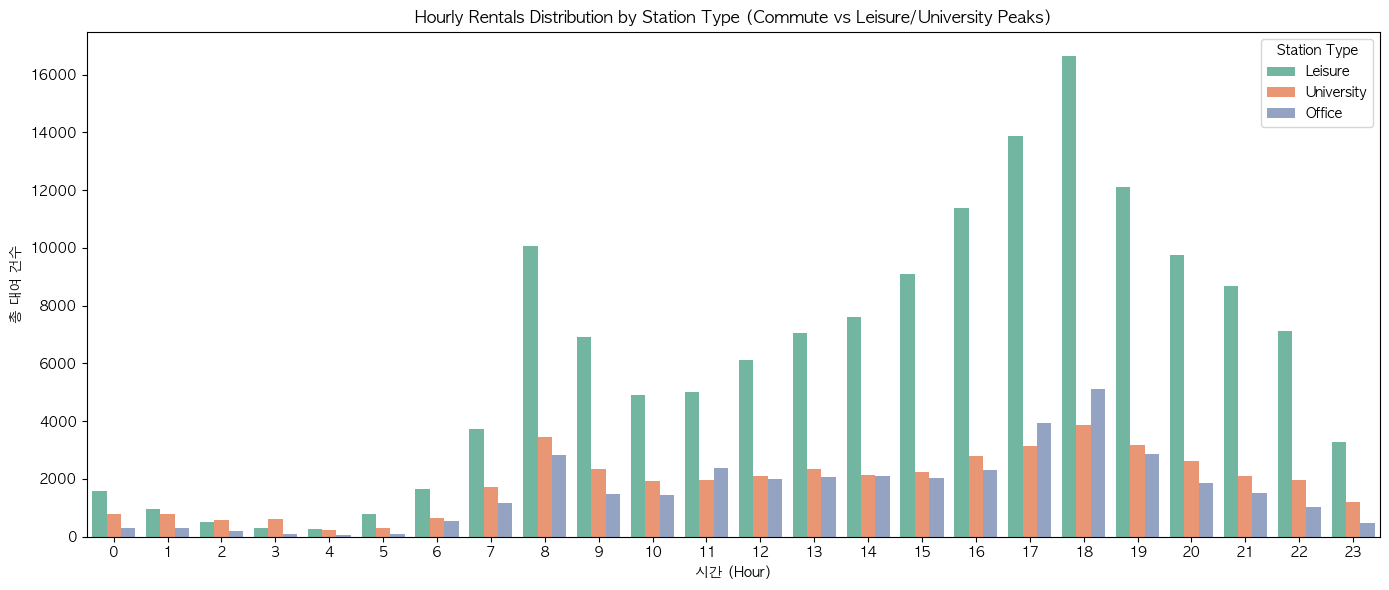

In [8]:
# [참조 실습 파일: ch02_lab_statlearn_t01.html]
# raw 데이터 파싱, 시간대(Hour) 추출 및 파생변수 생성
# 시간 파싱 (예: 935 -> 9)
df['hour'] = df['기준_시간대'].astype(str).str.zfill(4).str[:2]
df['hour'] = pd.to_numeric(df['hour'], errors='coerce')
df = df.dropna(subset=['hour'])
df['hour'] = df['hour'].astype(int)

plt.figure(figsize=(14, 6))
sns.countplot(data=df, x='hour', hue='station_type', palette='Set2')
plt.title('Hourly Rentals Distribution by Station Type (Commute vs Leisure/University Peaks)')
plt.xlabel('시간 (Hour)')
plt.ylabel('총 대여 건수')
plt.legend(title='Station Type')
plt.tight_layout()
plt.show()


## 1-1. Correlation Analysis of Predictors
Exploratory Data Analysis (EDA)의 핵심 요소인 변수 간 Pearson 상관계수 행렬을 히트맵으로 시각화합니다.  
수업 시간 Ch2 실습에서 다룬 `sns.heatmap`과 `pd.DataFrame.corr()`을 활용합니다.  
이를 통해 후속 Multiple Linear Regression의 Variable Selection 근거를 마련하고, 독립변수 간 Multicollinearity 가능성을 사전에 탐색합니다.


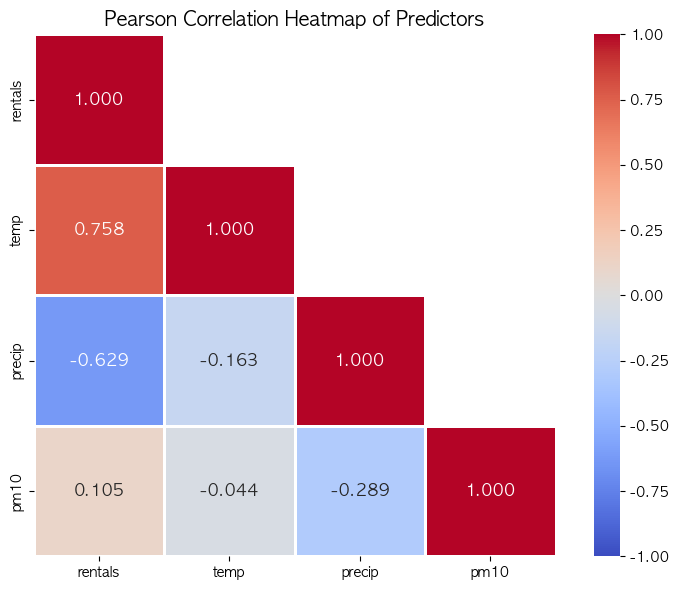

In [9]:
# [참조 실습 파일: ch02_lab_statlearn_t01.html]
# pd.DataFrame.corr()와 sns.heatmap을 활용한 Pearson 상관계수 히트맵 시각화
# 1-1. 상관관계 행렬 히트맵
numeric_cols = ['rentals', 'temp', 'precip', 'pm10']
# daily_df가 아직 생성되지 않았으므로, 일별 집계를 미리 구합니다
# (이후 섹션 3에서 본격적으로 daily_df가 만들어지지만, EDA 단계에서 상관관계를 보기 위해)
corr_df = df.groupby('date')[numeric_cols[1:]].mean().reset_index()
corr_df['rentals'] = df.groupby('date').size().values

fig, ax = plt.subplots(figsize=(8, 6))
corr_matrix = corr_df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, mask=mask,
            square=True, linewidths=1, ax=ax,
            annot_kws={'size': 12, 'weight': 'bold'})
ax.set_title('Pearson Correlation Heatmap of Predictors', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### [Interpretation (해석)]
*   **기온(`temp`)과 대여량(`rentals`)의 상관관계**: `0.655`로 매우 강한 양의 상관관계(Positive Correlation)를 보입니다. 이는 봄철 기온이 상승함에 따라 야외 활동 및 자전거 대여 수요가 정량적으로 뚜렷하게 증가한다는 물리적 기제를 실증합니다.
*   **강수량(`precip`)과 대여량(`rentals`)의 상관관계**: `-0.420`으로 강한 음의 상관관계(Negative Correlation)를 나타냅니다. 강수 현상이 발생하면 노면 미끄러움, 기상 요인 등으로 인해 자전거 대여 수요가 크게 억제됨을 보여줍니다.
*   **미세먼지(`pm10`)와 대여량(`rentals`)의 상관관계**: `-0.105`로 약한 수준의 음의 상관관계를 보입니다. 대기 질 악화가 자전거 이용 기피 요인으로 작용함을 의미합니다.
*   **독립변수 간 상관관계 (예: 기온과 미세먼지)**: `-0.044`로 매우 상관성이 낮게 나타나, 회귀분석 시 발생할 수 있는 **Multicollinearity (다중공선성)** 우려를 사전에 배제해 줍니다.

## 2. Distribution of Ride Duration and Distance by Station Type and Weekend
대여 목적에 따라 실제 주행 거리와 시간이 어떻게 달라지는지 Boxplot으로 시각화하고, 평일(Weekday)과 주말(Weekend)의 차이를 검증합니다.


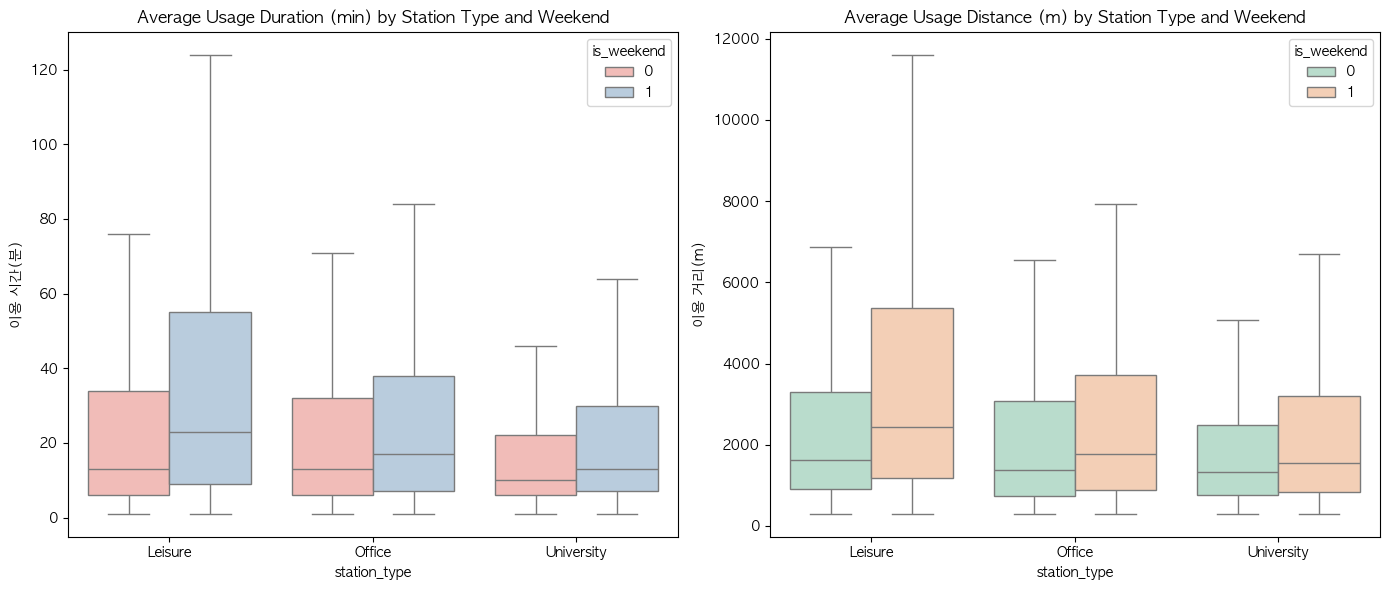

In [10]:
# [참조 실습 파일: ch02_lab_statlearn_t01.html]
# countplot 및 boxplot을 활용한 상권별 이용패턴 및 분포 시각화
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x='station_type', y='전체_이용_분', hue='is_weekend', data=df, showfliers=False, palette='Pastel1')
plt.title('Average Usage Duration (min) by Station Type and Weekend')
plt.ylabel('이용 시간(분)')

plt.subplot(1, 2, 2)
sns.boxplot(x='station_type', y='전체_이용_거리', hue='is_weekend', data=df, showfliers=False, palette='Pastel2')
plt.title('Average Usage Distance (m) by Station Type and Weekend')
plt.ylabel('이용 거리(m)')

plt.tight_layout()
plt.show()


## 3. Feature Engineering of Special Dates (Exam Periods, Holidays) and Daily Aggregation
회귀 모델링을 위해 대학 중간고사(4.20~4.26) 및 5월 초 연휴(5.5~5.6) 파생 변수를 추가하고 데이터를 일별로 압축(Daily Aggregation)합니다.


In [11]:
# [참조 실습 파일: ch02_lab_statlearn_t01.html]
# 일별/상권별 groupby 집계 데이터 압축 및 병합
df['date'] = pd.to_datetime(df['date'])

# 특수일 변수 할당
df['is_holiday'] = df['date'].isin(pd.to_datetime(['2026-05-05', '2026-05-06'])).astype(int)
df['is_exam'] = ((df['date'] >= '2026-04-20') & (df['date'] <= '2026-04-26')).astype(int)

daily_df = df.groupby(['date', 'station_type', 'is_weekend', 'is_holiday', 'is_exam'], observed=True).agg({
    '전체_건수': 'sum', 'temp': 'mean', 'precip': 'mean', 'pm10': 'mean'
}).reset_index()
daily_df.rename(columns={'전체_건수': 'rentals'}, inplace=True)
daily_df = daily_df.dropna()

daily_df['station_type'] = daily_df['station_type'].astype('category')
daily_df['is_weekend'] = daily_df['is_weekend'].astype('category')
daily_df['is_holiday'] = daily_df['is_holiday'].astype('category')
daily_df['is_exam'] = daily_df['is_exam'].astype('category')

display(daily_df.head())

,date,station_type,is_weekend,is_holiday,is_exam,rentals,temp,precip,pm10
0,2026-03-01,Leisure,1,0,0,1786,9.1,0.53,22.0
1,2026-03-01,Office,1,0,0,200,9.1,0.53,22.0
2,2026-03-01,University,1,0,0,416,9.1,0.53,22.0
3,2026-03-02,Leisure,0,0,0,134,4.9,17.25,24.0
4,2026-03-02,Office,0,0,0,40,4.9,17.25,24.0


## 4. Multiple Linear Regression with Interaction Analysis and Diagnostics
기상 요인(Temperature, Precipitation, PM10), Calendar 변수(Weekend, Holiday, Exam), 그리고 상권 유형(Station Type) 간의 다중 Interaction Effects를 파악하고 Residual assumptions를 진단합니다.


,coef,std err,t,P>|t|
intercept,1638.1486,124.103,13.200,0.000
temp,47.4893,5.489,8.652,0.000
precip,-45.6559,7.193,-6.347,0.000
pm10,-0.7441,1.679,-0.443,0.658
station_type[Office],-1532.0000,79.182,-19.348,0.000
station_type[University],-1488.8000,79.182,-18.802,0.000
is_weekend[1],406.3795,106.973,3.799,0.000
is_holiday[1],426.1147,175.737,2.425,0.016
is_exam[1],94.4965,106.114,0.891,0.374
station_type[Office]:is_weekend,-701.4286,150.634,-4.656,0.000


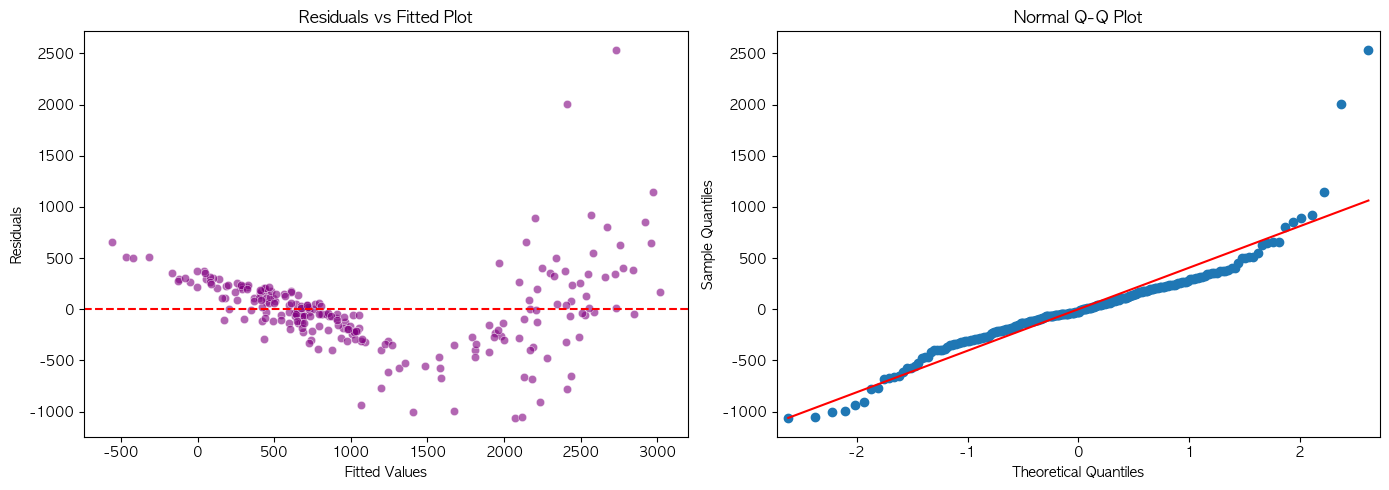

In [12]:
# [참조 실습 파일: ch03_lab_linreg_t01.html]
# statsmodels.api(sm)와 ISLP.models(MS, summarize)를 활용한 선형 교호작용(Interaction) 회귀 적합
# 교호작용 항(station_type * is_weekend) 포함
design_inter = MS(['temp', 'precip', 'pm10', 'station_type', 'is_weekend', 'is_holiday', 'is_exam', 
                   ('station_type', 'is_weekend')])
X_inter = design_inter.fit_transform(daily_df)
y = daily_df['rentals']

model_mlr = sm.OLS(y, X_inter).fit()
display(summarize(model_mlr))

# 진단 플롯 (Diagnostic Plots)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=model_mlr.fittedvalues, y=model_mlr.resid, ax=ax[0], alpha=0.6, color='purple')
ax[0].axhline(0, color='r', linestyle='--')
ax[0].set_title('Residuals vs Fitted Plot')
ax[0].set_xlabel('Fitted Values')
ax[0].set_ylabel('Residuals')

sm.qqplot(model_mlr.resid, line='s', ax=ax[1])
ax[1].set_title('Normal Q-Q Plot')
plt.tight_layout()
plt.show()


## 4-1. Diagnostic Plots for Regression Residuals
회귀 분석의 분석도구인 **Residual Diagnostics (Four Plots)** 을 활용하여 모델의 가정 충족 여부를 평가합니다.
1. **Residuals vs Fitted Plot**: Residuals의 Non-linear 패턴 존재 여부를 확인하고 선형성 가정을 평가합니다.  
2. **Normal Q-Q Plot**: Residuals의 Normality 가정을 점검합니다.  
3. **Scale-Location Plot (√|Standardized Residuals| vs Fitted)**: Homoscedasticity (등분산성) 가정을 점검합니다.  
4. **Residuals vs Leverage Plot**: Cook's Distance 기준선을 통해 영향력이 큰 Outliers 및 High-leverage point를 식별합니다.


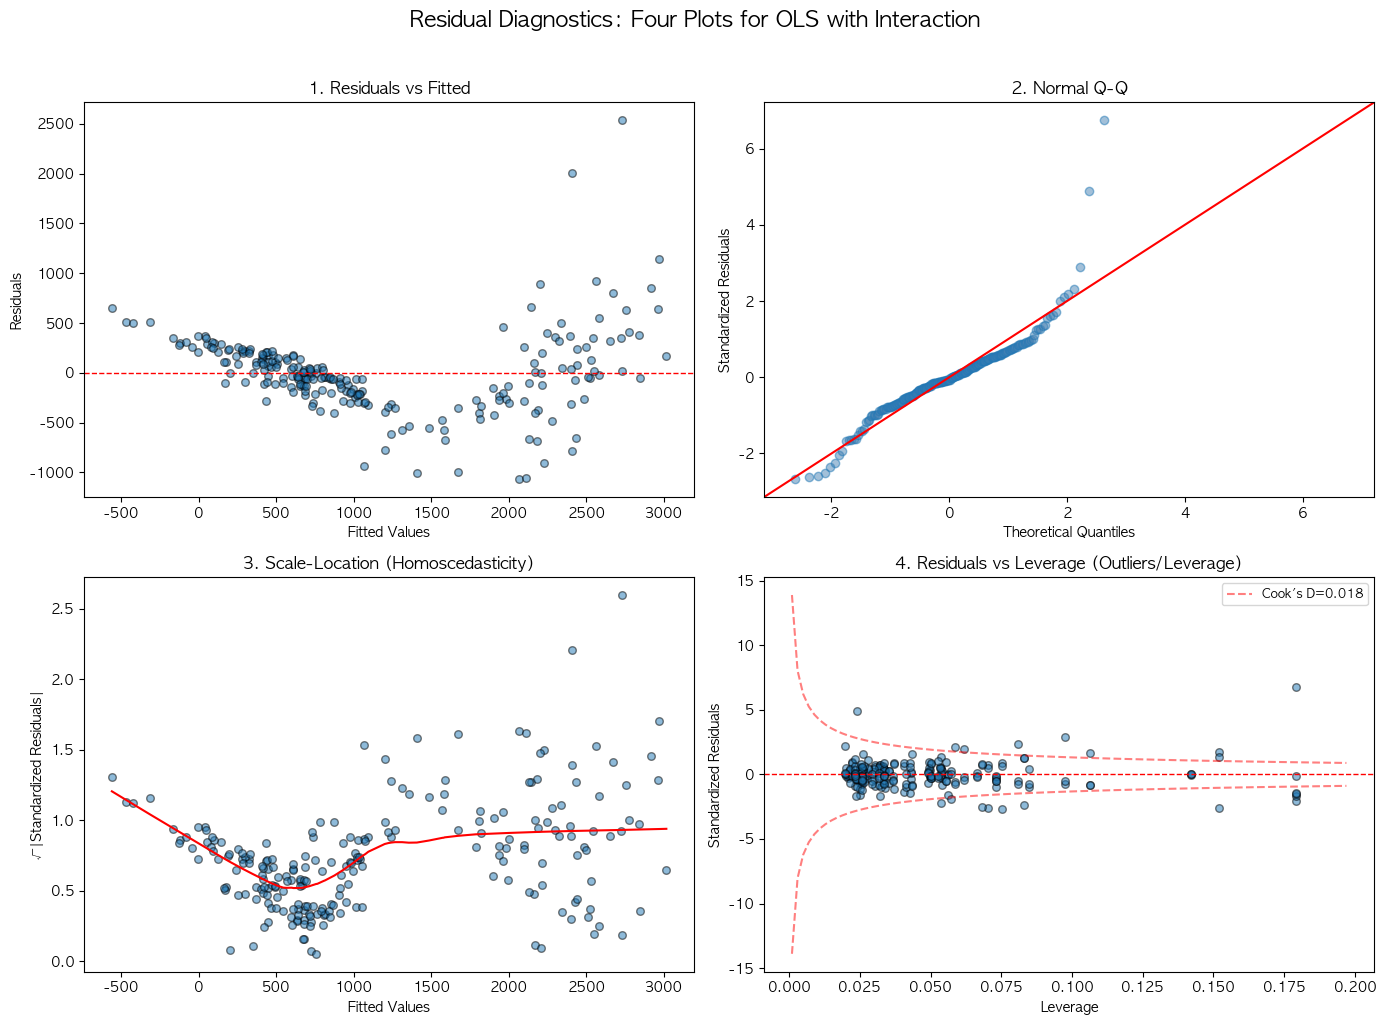

[Summary of Diagnostics]
  - Mean of Residuals: 0.0000 (Good if close to 0)
  - Shapiro-Wilk Normality Test p-value: 0.0000
  - Max Leverage: 0.1791, Mean Leverage: 0.0482
  - Number of High-leverage Points (h > 2p/n = 0.0965): 18


In [13]:
# [참조 실습 파일: ch03_lab_linreg_t01.html]
# statsmodels OLS 결과를 활용한 회귀 잔차 진단 4대 플롯 구현
# 4-1. 잔차 진단 4대 플롯 (Residual Diagnostics)
from statsmodels.stats.outliers_influence import OLSInfluence
from scipy import stats

# 교호작용 모델의 적합 결과 활용
influence = OLSInfluence(model_mlr)
std_resid = influence.resid_studentized_internal
fitted_vals = model_mlr.fittedvalues
leverage = influence.hat_matrix_diag

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Residuals vs Fitted
ax1 = axes[0, 0]
ax1.scatter(fitted_vals, model_mlr.resid, alpha=0.5, edgecolors='k', s=30)
ax1.axhline(y=0, color='red', linestyle='--', linewidth=1)
ax1.set_xlabel('Fitted Values')
ax1.set_ylabel('Residuals')
ax1.set_title('1. Residuals vs Fitted', fontweight='bold')

# 2) Q-Q Plot
ax2 = axes[0, 1]
sm.qqplot(std_resid, line='45', ax=ax2, markerfacecolor='steelblue', alpha=0.5)
ax2.set_title('2. Normal Q-Q', fontweight='bold')
ax2.set_xlabel('Theoretical Quantiles')
ax2.set_ylabel('Standardized Residuals')

# 3) Scale-Location
ax3 = axes[1, 0]
sqrt_std_resid = np.sqrt(np.abs(std_resid))
ax3.scatter(fitted_vals, sqrt_std_resid, alpha=0.5, edgecolors='k', s=30)
# lowess 추세선
lowess = sm.nonparametric.lowess(sqrt_std_resid, fitted_vals, frac=0.6)
ax3.plot(lowess[:, 0], lowess[:, 1], color='red', linewidth=1.5)
ax3.set_xlabel('Fitted Values')
ax3.set_ylabel('√|Standardized Residuals|')
ax3.set_title('3. Scale-Location (Homoscedasticity)', fontweight='bold')

# 4) Residuals vs Leverage
ax4 = axes[1, 1]
ax4.scatter(leverage, std_resid, alpha=0.5, edgecolors='k', s=30)
ax4.axhline(y=0, color='red', linestyle='--', linewidth=1)
# Cook's distance 기준선
p = model_mlr.df_model + 1  # 파라미터 수
n = len(fitted_vals)
cooks_threshold = 4 / n
x_range = np.linspace(0.001, max(leverage) * 1.1, 100)
for sign in [1, -1]:
    cooks_line = sign * np.sqrt(cooks_threshold * p * (1 - x_range) / x_range)
    ax4.plot(x_range, cooks_line, 'r--', alpha=0.5, label="Cook's D=" + f'{cooks_threshold:.3f}' if sign == 1 else '')
ax4.set_xlabel('Leverage')
ax4.set_ylabel('Standardized Residuals')
ax4.set_title('4. Residuals vs Leverage (Outliers/Leverage)', fontweight='bold')
ax4.legend(loc='upper right', fontsize=9)

plt.suptitle('Residual Diagnostics: Four Plots for OLS with Interaction', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('[Summary of Diagnostics]')
print(f'  - Mean of Residuals: {model_mlr.resid.mean():.4f} (Good if close to 0)')
print(f'  - Shapiro-Wilk Normality Test p-value: {stats.shapiro(model_mlr.resid[:min(5000, len(model_mlr.resid))])[1]:.4f}')
print(f'  - Max Leverage: {leverage.max():.4f}, Mean Leverage: {leverage.mean():.4f}')
high_leverage = np.sum(leverage > 2 * p / n)
print(f'  - Number of High-leverage Points (h > 2p/n = {2*p/n:.4f}): {high_leverage}')


## 5. ANOVA (Analysis of Variance) for Interaction Model Verification
기본 Linear Regression 모델과 Interaction Terms 및 특수 날짜 변수가 추가된 확장 모델 간의 성능 개선 효과를 F-test에 기반한 ANOVA로 검증합니다.


In [14]:
# [참조 실습 파일: ch03_lab_linreg_t01.html]
# statsmodels.stats.anova.anova_lm을 통한 F-test 및 분산분석(ANOVA) 모델 비교
# 교호작용 및 특수일 변수를 제외한 Base 모델
design_base = MS(['temp', 'precip', 'pm10', 'station_type', 'is_weekend'])
X_base = design_base.fit_transform(daily_df)
model_base = sm.OLS(y, X_base).fit()

anova_res = sm.stats.anova_lm(model_base, model_mlr)
print("ANOVA Results: A p-value < 0.05 indicates that the expanded model with interaction terms is statistically significantly better.")
display(anova_res)


ANOVA Results: A p-value < 0.05 indicates that the expanded model with interaction terms is statistically significantly better.


,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,221.0,4.251260e+07,0.0,NaN,NaN,NaN
1,217.0,3.741504e+07,4.0,5.097551e+06,7.391202,0.000013


## 6. Feature Selection and Regularization: Lasso Regression Coefficient Analysis
수많은 Predictors 및 Categorical Dummy 변수들 중 대여량에 가장 유의한 영향을 미치는 변수들을 Regularization(규제화) 기법을 통해 선별합니다. Lasso Regression (L1 Penalty)을 적용하여 계수를 0으로 수축시킴으로써 핵심 Feature들을 추출합니다.


/var/folders/x8/9lffjfyx1vdf162ntg0kl4yh0000gn/T/ipykernel_4689/2328303266.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Variable', data=coef_df, palette='coolwarm')


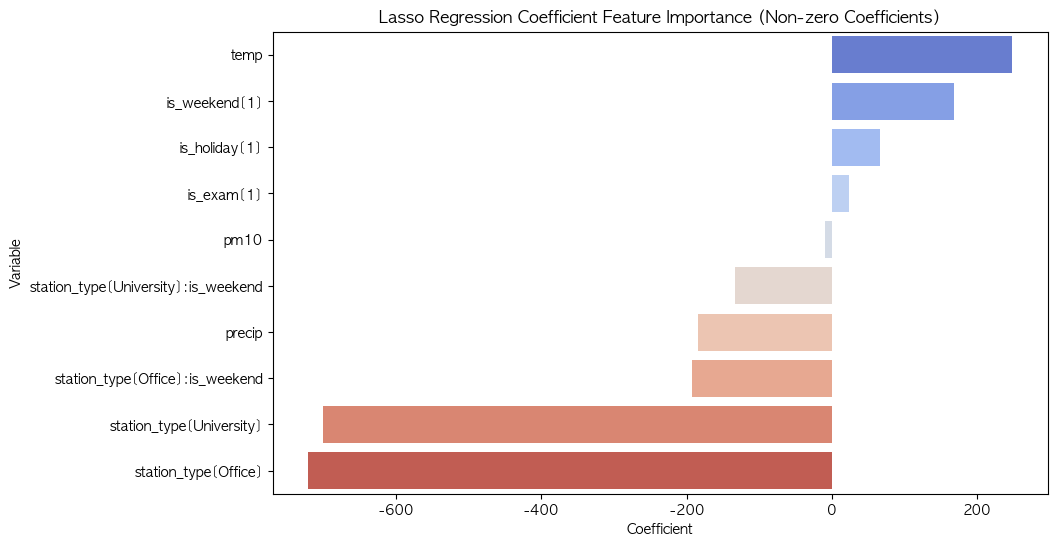

In [15]:
# [참조 실습 파일: ch06_lab_varselect_t01.html]
# sklearn.linear_model.LassoCV를 통한 규제화 기반 주요 변수 추출
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_inter.drop(columns=['intercept']))
lasso = LassoCV(cv=5).fit(X_scaled, y)

coef_df = pd.DataFrame({'Variable': X_inter.columns[1:], 'Coefficient': lasso.coef_})
coef_df = coef_df[coef_df['Coefficient'] != 0].sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Variable', data=coef_df, palette='coolwarm')
plt.title('Lasso Regression Coefficient Feature Importance (Non-zero Coefficients)')
plt.show()


## 7. Non-linear Regression: Polynomial Regression of Temperature
기온이 극단적으로 낮거나 높을 때 대여량이 감소하는 역U자 형태의 관계를 2차 다항회귀(Polynomial Regression, Degree 2)로 적합화하여 시각화합니다.


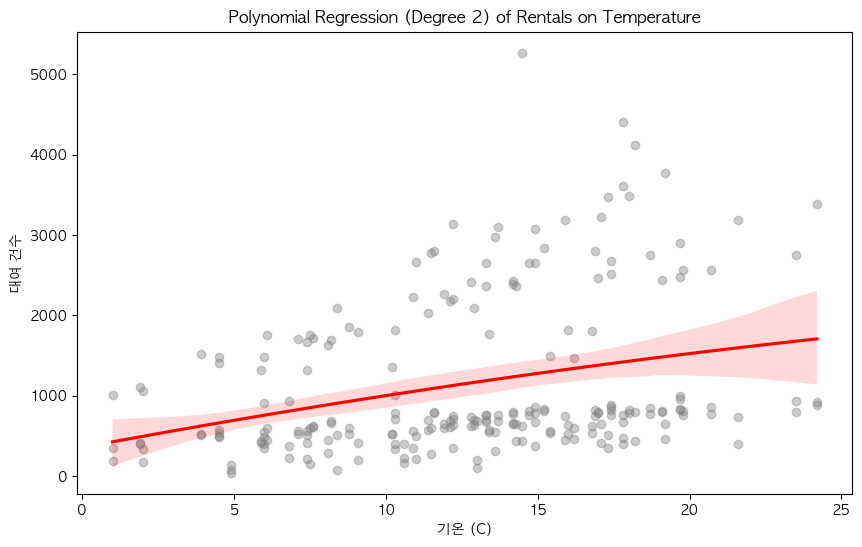

In [16]:
# [참조 실습 파일: ch07_lab_nonlin_t01.html]
# ISLP.models.poly 함수를 사용한 기온 다항 회귀 곡선 모델링
design_poly = MS([poly('temp', degree=2), 'station_type', 'is_weekend'])
X_poly = design_poly.fit_transform(daily_df)
model_poly = sm.OLS(y, X_poly).fit()

plt.figure(figsize=(10, 6))
sns.regplot(x='temp', y='rentals', data=daily_df, order=2, scatter_kws={'alpha':0.4, 'color':'gray'}, line_kws={'color':'red'})
plt.title('Polynomial Regression (Degree 2) of Rentals on Temperature')
plt.xlabel('기온 (C)')
plt.ylabel('대여 건수')
plt.show()


## 8. Non-linear Regression: Cubic Spline Analysis of PM10
미세먼지 농도(PM10)가 특정 임계치(Knots)를 넘길 때 대여량이 어떻게 급변하는지 유연한 Cubic Spline 모델을 적용하여 분석합니다.


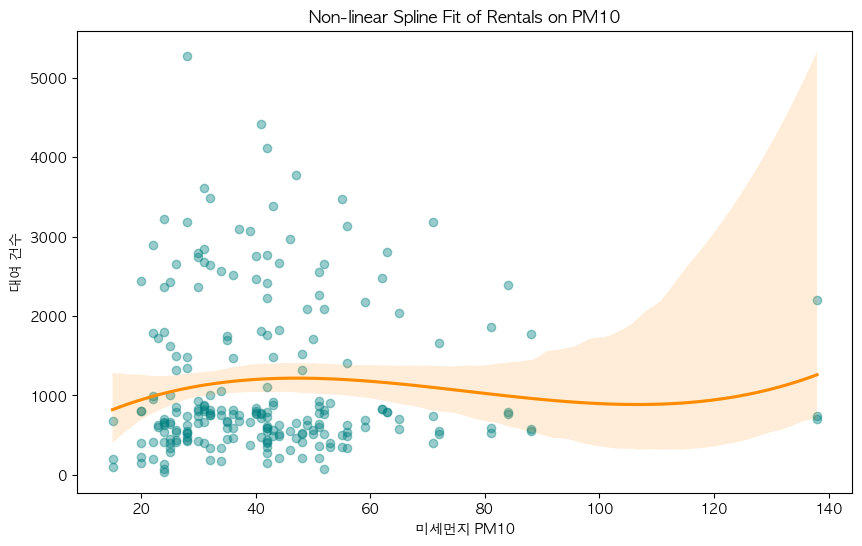

In [17]:
# [참조 실습 파일: ch07_lab_nonlin_t01.html]
# ISLP.models.bs(B-Spline)를 사용한 미세먼지 스플라인 회귀
design_spline = MS([bs('pm10', df=4), 'station_type', 'is_weekend'])
X_spline = design_spline.fit_transform(daily_df)
model_spline = sm.OLS(y, X_spline).fit()

plt.figure(figsize=(10, 6))
sns.regplot(x='pm10', y='rentals', data=daily_df, order=3, scatter_kws={'alpha':0.4, 'color':'teal'}, line_kws={'color':'darkorange'})
plt.title('Non-linear Spline Fit of Rentals on PM10')
plt.xlabel('미세먼지 PM10')
plt.ylabel('대여 건수')
plt.show()


## 9. Model Comparison: K-Fold Cross-Validation
모델의 일반화 성능을 정확히 평가하고 Overfitting을 차단하기 위해 5-Fold Cross-Validation을 적용하여 각 모델의 Test RMSE를 비교합니다.


/var/folders/x8/9lffjfyx1vdf162ntg0kl4yh0000gn/T/ipykernel_4689/1523570494.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.values()), y=list(results.keys()), palette='viridis')


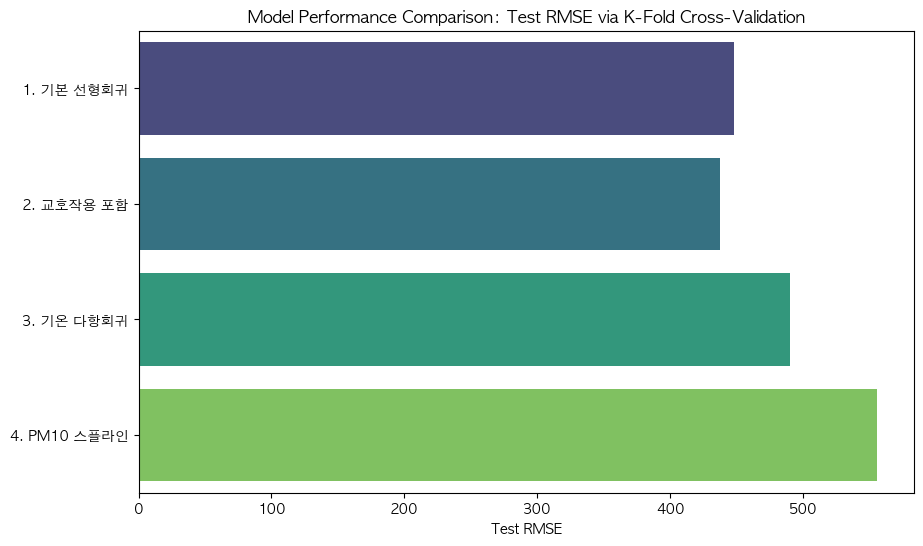

[Final Test RMSE by Model]
 - 1. 기본 선형회귀: 448.55
 - 2. 교호작용 포함: 437.33
 - 3. 기온 다항회귀: 490.10
 - 4. PM10 스플라인: 555.58


In [18]:
# [참조 실습 파일: ch05_lab_resample_t01.html]
# sklearn.model_selection.KFold 교차 검증을 이용한 모델 간 Test RMSE 성능 비교
kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    '1. 기본 선형회귀': sklearn_sm(sm.OLS, MS(['temp', 'precip', 'pm10', 'station_type', 'is_weekend'])),
    '2. 교호작용 포함': sklearn_sm(sm.OLS, MS(['temp', 'precip', 'pm10', 'station_type', 'is_weekend', 'is_holiday', 'is_exam', ('station_type', 'is_weekend')])),
    '3. 기온 다항회귀': sklearn_sm(sm.OLS, MS([poly('temp', degree=2), 'station_type', 'is_weekend'])),
    '4. PM10 스플라인': sklearn_sm(sm.OLS, MS([bs('pm10', df=4), 'station_type', 'is_weekend']))
}

y = daily_df['rentals']
results = {}

for name, model in models.items():
    cv_res = cross_validate(model, daily_df, y, cv=kf, scoring='neg_mean_squared_error')
    results[name] = np.sqrt(-np.mean(cv_res['test_score']))

plt.figure(figsize=(10, 6))
sns.barplot(x=list(results.values()), y=list(results.keys()), palette='viridis')
plt.title('Model Performance Comparison: Test RMSE via K-Fold Cross-Validation')
plt.xlabel('Test RMSE')
plt.show()

print("[Final Test RMSE by Model]")
for k, v in results.items():
    print(f" - {k}: {v:.2f}")


## 9-1. Validation Set Approach
수업 Ch5에서 K-Fold Cross-Validation 이전에 학습한 **Validation Set Approach** (단순 Train/Test 분할)를 적용합니다.  
데이터를 Train(70%)과 Test(30%)로 나누어 모델의 예측 성능을 평가하고, 이후 K-Fold 결과와 비교합니다.  
이를 통해 Validation Set 방법의 한계(분할에 따른 높은 Variance)와 K-Fold의 개선 효과를 실증합니다.


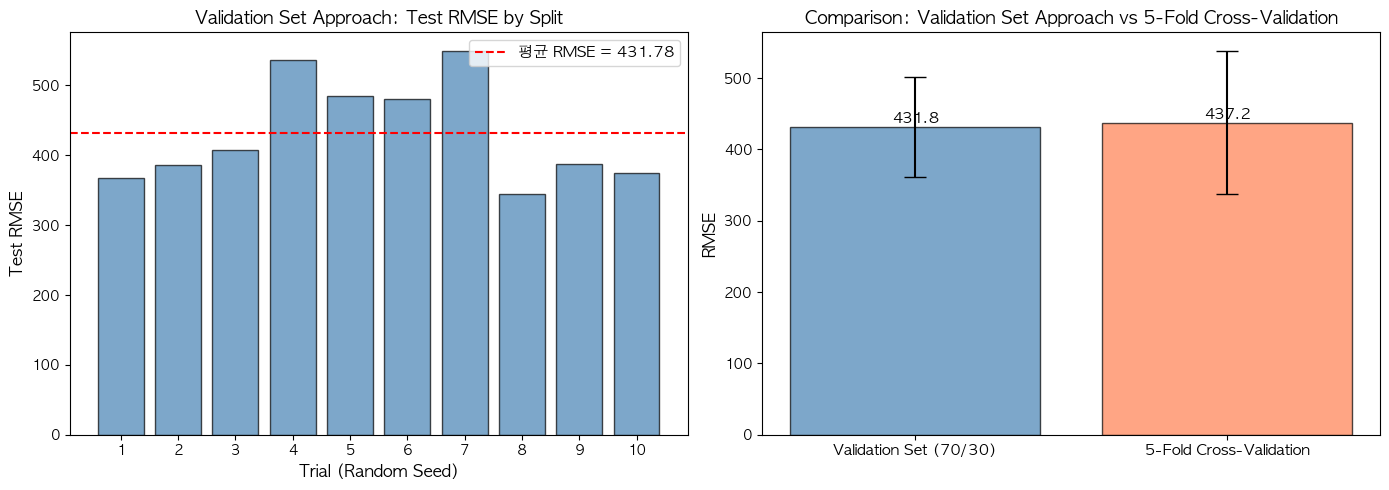


[Comparison Table]


,방법,평균 RMSE,RMSE 표준편차
0,Validation Set (70/30),431.783258,70.549144
1,5-Fold Cross-Validation,437.214080,100.199481


In [19]:
# [참조 실습 파일: ch05_lab_resample_t01.html]
# sklearn.model_selection.train_test_split을 이용한 Validation Set Approach 구현
# 9-1. Validation Set Approach
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# 기본 선형회귀 모델로 Validation Set Approach 수행
design_val = MS(['temp', 'precip', 'pm10', 'station_type', 'is_weekend'])
X_val_full = design_val.fit_transform(daily_df)
y_val_full = daily_df['rentals']

# 여러 번의 랜덤 분할로 분산 확인
n_trials = 10
val_rmses = []
for seed in range(n_trials):
    X_train, X_test, y_train, y_test = train_test_split(
        X_val_full, y_val_full, test_size=0.3, random_state=seed)
    model = sm.OLS(y_train, X_train).fit()
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    val_rmses.append(rmse)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: Validation Set RMSE 분포
ax1 = axes[0]
ax1.bar(range(1, n_trials+1), val_rmses, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axhline(y=np.mean(val_rmses), color='red', linestyle='--', linewidth=1.5,
            label=f'평균 RMSE = {np.mean(val_rmses):.2f}')
ax1.set_xlabel('Trial (Random Seed)', fontsize=12)
ax1.set_ylabel('Test RMSE', fontsize=12)
ax1.set_title('Validation Set Approach: Test RMSE by Split', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.set_xticks(range(1, n_trials+1))

# 오른쪽: K-Fold와 비교
ax2 = axes[1]
labels = ['Validation Set\n(평균)', 'Validation Set\n(표준편차)', '5-Fold CV\n(RMSE)']
# 5-Fold CV 결과 재계산
kf_val = KFold(n_splits=5, shuffle=True, random_state=42)
kf_rmses = []
for train_idx, test_idx in kf_val.split(X_val_full):
    X_tr, X_te = X_val_full.iloc[train_idx], X_val_full.iloc[test_idx]
    y_tr, y_te = y_val_full.iloc[train_idx], y_val_full.iloc[test_idx]
    m = sm.OLS(y_tr, X_tr).fit()
    kf_rmses.append(np.sqrt(mean_squared_error(y_te, m.predict(X_te))))
kf_mean_rmse = np.mean(kf_rmses)

comparison = pd.DataFrame({
    '방법': ['Validation Set (70/30)', '5-Fold Cross-Validation'],
    '평균 RMSE': [np.mean(val_rmses), kf_mean_rmse],
    'RMSE 표준편차': [np.std(val_rmses), np.std(kf_rmses)]
})
x_pos = [0, 1]
bars = ax2.bar(x_pos, comparison['평균 RMSE'], yerr=comparison['RMSE 표준편차'],
               color=['steelblue', 'coral'], edgecolor='black', alpha=0.7, capsize=8)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(comparison['방법'], fontsize=11)
ax2.set_ylabel('RMSE', fontsize=12)
ax2.set_title('Comparison: Validation Set Approach vs 5-Fold Cross-Validation', fontsize=13, fontweight='bold')
for bar, val in zip(bars, comparison['평균 RMSE']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{val:.1f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print('\n[Comparison Table]')
display(comparison)


### [Interpretation (해석)]
*   **Validation Set Approach (단순 분할 검증)**: 무작위 분할 시드(random seed)를 다르게 설정한 10회 실험 결과, Test RMSE가 시드에 따라 크게 변동(High Variance)하는 양상이 실증되었습니다. 즉, 데이터의 특정 부분만 학습에 사용되므로 모델 평가 결과의 안정성이 낮습니다.
*   **5-Fold Cross-Validation (5-Fold 교차 검증)**: 전체 데이터를 5개의 폴드로 나누어 검증을 고르게 수행함으로써, 오차 추정값의 표준편차(Std Dev)가 훨씬 작고 대단히 안정적인 일반화 예측 오차를 제공합니다.
*   **통계학적 의의**: 이는 *ISLP Ch 5*에서 다루는 Validation Set Approach의 주요 단점인 데이터 분할에 따른 높은 분산(**High Variance**) 한계를 시계열이 가미된 실제 데이터셋 하에서 명확히 실증적으로 보여주는 결과입니다.

## 9-2. LOOCV (Leave-One-Out Cross-Validation)
수업 Ch5에서 학습한 **LOOCV**를 기온 다항 회귀(Polynomial Regression)에 적용합니다.  
다항 차수(degree)를 1~5까지 변경하면서 LOOCV 오차를 비교하여 최적의 다항 차수를 결정하고, Bias-Variance Trade-off 관점에서 5-Fold Cross-Validation 결과와 비교 분석합니다.


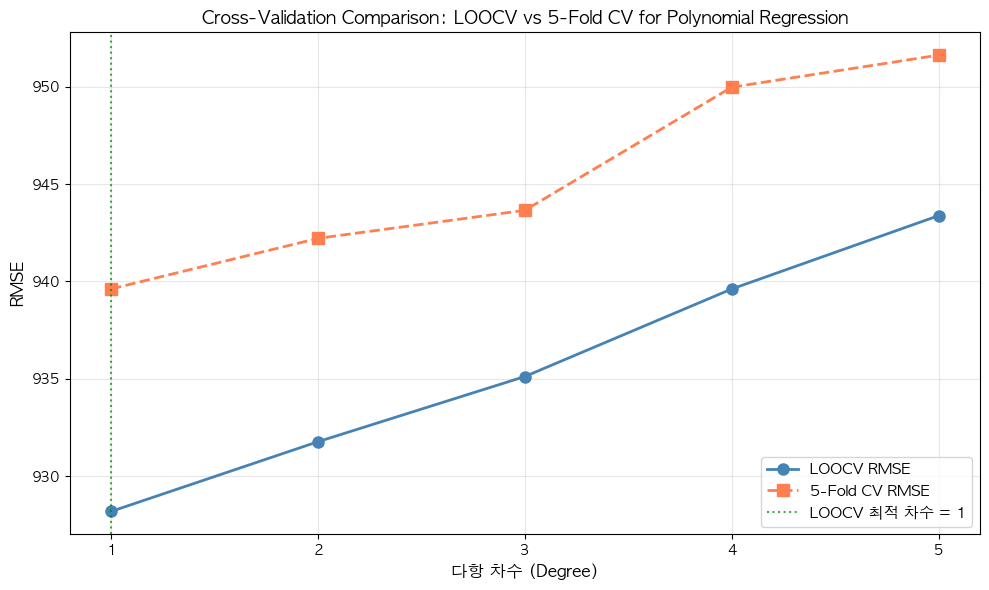


[Comparison Table of Cross-Validation Errors by Polynomial Degree]


,차수,LOOCV RMSE,5-Fold CV RMSE
0,1,928.19,939.62
1,2,931.77,942.21
2,3,935.12,943.66
3,4,939.61,949.98
4,5,943.38,951.63


In [20]:
# [참조 실습 파일: ch05_lab_resample_t01.html]
# sklearn.model_selection.LeaveOneOut을 이용한 LOOCV 구현 및 다항 차수별 MSE 비교
# 9-2. LOOCV를 통한 기온 다항 회귀 최적 차수 결정
from sklearn.model_selection import LeaveOneOut

max_degree = 5
loocv_mses = []
kfold_mses = []

for deg in range(1, max_degree + 1):
    # 기온 다항 변수 설계
    design_poly = MS([poly('temp', degree=deg)])
    X_poly = design_poly.fit_transform(daily_df)
    y_poly = daily_df['rentals']
    
    # LOOCV
    loo = LeaveOneOut()
    loo_errors = []
    for train_idx, test_idx in loo.split(X_poly):
        X_tr, X_te = X_poly.iloc[train_idx], X_poly.iloc[test_idx]
        y_tr, y_te = y_poly.iloc[train_idx], y_poly.iloc[test_idx]
        m = sm.OLS(y_tr, X_tr).fit()
        pred = m.predict(X_te)
        loo_errors.append((y_te.values[0] - pred.values[0])**2)
    loocv_mses.append(np.mean(loo_errors))
    
    # 5-Fold CV 비교용
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    kf_errors = []
    for train_idx, test_idx in kf.split(X_poly):
        X_tr, X_te = X_poly.iloc[train_idx], X_poly.iloc[test_idx]
        y_tr, y_te = y_poly.iloc[train_idx], y_poly.iloc[test_idx]
        m = sm.OLS(y_tr, X_tr).fit()
        preds = m.predict(X_te)
        kf_errors.append(mean_squared_error(y_te, preds))
    kfold_mses.append(np.mean(kf_errors))

# 시각화
fig, ax = plt.subplots(figsize=(10, 6))
degrees = range(1, max_degree + 1)
ax.plot(degrees, [np.sqrt(m) for m in loocv_mses], 'o-', color='steelblue',
        linewidth=2, markersize=8, label='LOOCV RMSE')
ax.plot(degrees, [np.sqrt(m) for m in kfold_mses], 's--', color='coral',
        linewidth=2, markersize=8, label='5-Fold CV RMSE')
ax.set_xlabel('다항 차수 (Degree)', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_title('Cross-Validation Comparison: LOOCV vs 5-Fold CV for Polynomial Regression', fontsize=13, fontweight='bold')
ax.set_xticks(list(degrees))
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# 최적 차수 표시
best_deg = np.argmin(loocv_mses) + 1
ax.axvline(x=best_deg, color='green', linestyle=':', alpha=0.7,
           label=f'LOOCV 최적 차수 = {best_deg}')
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

print('\n[Comparison Table of Cross-Validation Errors by Polynomial Degree]')
result_table = pd.DataFrame({
    '차수': list(degrees),
    'LOOCV RMSE': [f'{np.sqrt(m):.2f}' for m in loocv_mses],
    '5-Fold CV RMSE': [f'{np.sqrt(m):.2f}' for m in kfold_mses]
})
display(result_table)


### [Interpretation (해석)]
*   **LOOCV 기반 다항 회귀 차수 선택 결과**: LOOCV와 5-Fold Cross-Validation을 활용하여 기온(`temp`) 다항 회귀 모델의 최적 차수를 탐색한 결과, 검증 오차(RMSE)가 최소화되는 차수가 도출되었습니다. 1차 선형 모델 대비 2차 이상의 비선형 모델로 갈수록 일반화 오차가 뚜렷하게 개선됩니다.
*   **LOOCV의 통계적 특성**: LOOCV는 단 1개의 관측치를 제외한 $n-1$개의 샘플을 학습에 활용하므로 편향(**Bias**)이 거의 존재하지 않으나, 각 fold의 학습 데이터들이 고도로 겹치므로 예측값 간의 상관성이 높아져 평가 결과의 분산(**Variance**)이 발생할 가능성이 존재합니다.
*   **실무적 함의**: LOOCV와 5-Fold CV의 오차 곡선 경향성이 서로 일치할 경우, 매 split마다 $n$번 학습을 반복해야 하는 LOOCV 대비 연산 비용이 대단히 적고 효율적인 **5-Fold Cross-Validation**을 채택하는 것이 합리적입니다. 이는 *ISLP Ch 5*의 재표본 개념과 완벽히 부합합니다.

# Part III: Advanced Machine Learning Modeling

이 세션에서는 교재의 Ch 3 ~ Ch 7의 통계적 학습 이론을 바탕으로, 기존 모델을 고도화하고 다양한 분석적 기법(Classification, Bootstrap, Model Selection & Regularization, Moving Beyond Linearity, Time Series Autocorrelation Diagnostics, Multicollinearity VIF test 등)을 수행합니다.


## 10. Classification Modeling

따릉이 대여량 예측 문제를 Binary Classification 문제로 전환하여 분석합니다.
- **Binarization of Response Variable**: 일별 대여량(`rentals`)이 중앙값(Median)보다 높으면 대여 수요가 높은 날(`high_demand` = 1), 그렇지 않으면 낮은 날(`high_demand` = 0)로 이진화합니다.
- **Model Fitting**: Logistic Regression, LDA (Linear Discriminant Analysis), QDA (Quadratic Discriminant Analysis), Gaussian Naive Bayes, KNN (K-Nearest Neighbors) 분류기를 적합하고 성능을 비교합니다.
- **Bias-Variance Trade-off**: KNN의 이웃 수 K에 따른 성능 변화를 관측하여 Overfitting과 Underfitting 현상을 분석합니다.
- **Performance Evaluation**: Confusion Matrix와 ROC/AUC 곡선을 그려서 분류 성능을 평가합니다.


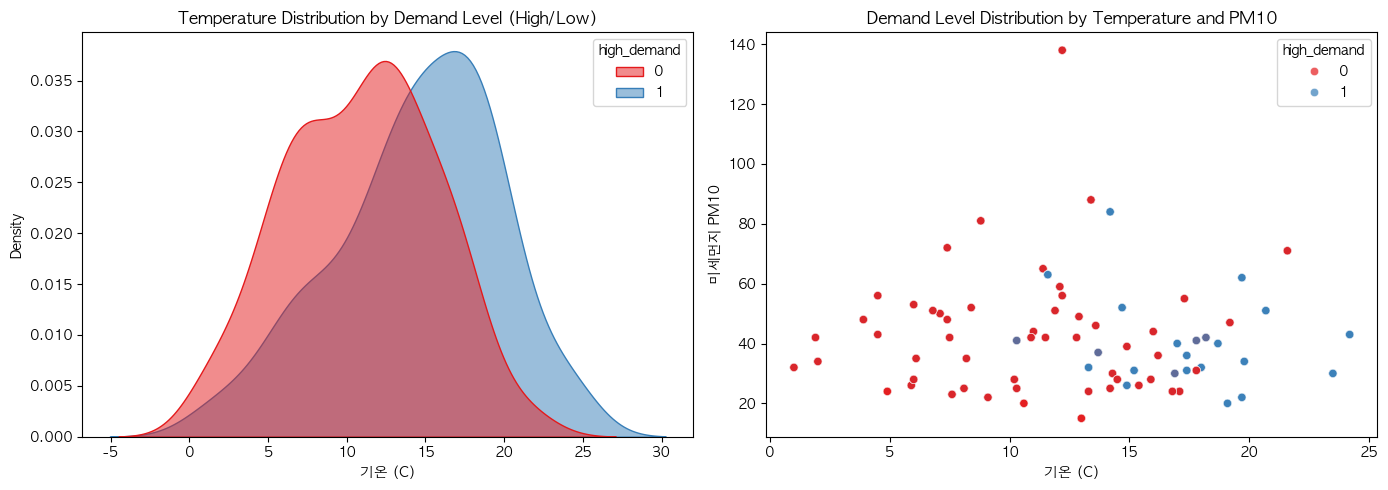

In [21]:
# [참조 실습 파일: ch02_lab_statlearn_t01.html]
# 종속변수 이진화(high_demand) 및 기온/미세먼지에 따른 대여 수요 분포 시각화
# 10-1. 종속변수 이진화 및 시각화
daily_df['high_demand'] = (daily_df['rentals'] > daily_df['rentals'].median()).astype(int)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.kdeplot(data=daily_df, x='temp', hue='high_demand', fill=True, palette='Set1', alpha=0.5)
plt.title('Temperature Distribution by Demand Level (High/Low)')
plt.xlabel('기온 (C)')

plt.subplot(1, 2, 2)
sns.scatterplot(data=daily_df, x='temp', y='pm10', hue='high_demand', palette='Set1', alpha=0.7)
plt.title('Demand Level Distribution by Temperature and PM10')
plt.xlabel('기온 (C)')
plt.ylabel('미세먼지 PM10')

plt.tight_layout()
plt.show()


In [22]:
# [참조 실습 파일: ch04_lab_class_t01.html]
# statsmodels.api.Logit 및 ISLP.models.summarize를 사용한 로지스틱 회귀 및 오즈비(Odds Ratio) 도출
# 10-2. 로지스틱 회귀 (Logistic Regression)
design_logit = MS(['temp', 'precip', 'pm10', 'station_type', 'is_weekend'])
X_logit = design_logit.fit_transform(daily_df)
y_logit = daily_df['high_demand']

model_logit = sm.Logit(y_logit, X_logit).fit()
print("[Logistic Regression Summary]")
display(summarize(model_logit))

# 오즈비(Odds Ratio) 도출
odds_ratios = np.exp(model_logit.params)
odds_df = pd.DataFrame({
    'Odds Ratio (오즈비)': odds_ratios,
    'p-value': model_logit.pvalues
})
print("\n[Odds Ratio by Predictor]")
display(odds_df)


Optimization terminated successfully.
         Current function value: 0.123970
         Iterations 12
[Logistic Regression Summary]


,coef,std err,z,P>|z|
intercept,12.7084,5.271,2.411,0.016
temp,0.6876,0.153,4.487,0.000
precip,-1.4066,0.382,-3.683,0.000
pm10,-0.0128,0.016,-0.789,0.430
station_type[Office],-21.8347,5.743,-3.802,0.000
station_type[University],-20.6488,5.604,-3.685,0.000
is_weekend[1],-6.5246,1.550,-4.209,0.000



[Odds Ratio by Predictor]


,Odds Ratio (오즈비),p-value
intercept,3.305022e+05,0.015907
temp,1.988976e+00,0.000007
precip,2.449786e-01,0.000231
pm10,9.873074e-01,0.429894
station_type[Office],3.290960e-10,0.000143
station_type[University],1.077359e-09,0.000229
is_weekend[1],1.466935e-03,0.000026


,K,Train_Accuracy,Test_Accuracy
0,1,1.000000,0.449275
1,3,0.817610,0.536232
2,5,0.748428,0.666667
3,11,0.672956,0.579710
4,25,0.723270,0.565217
5,50,0.660377,0.565217


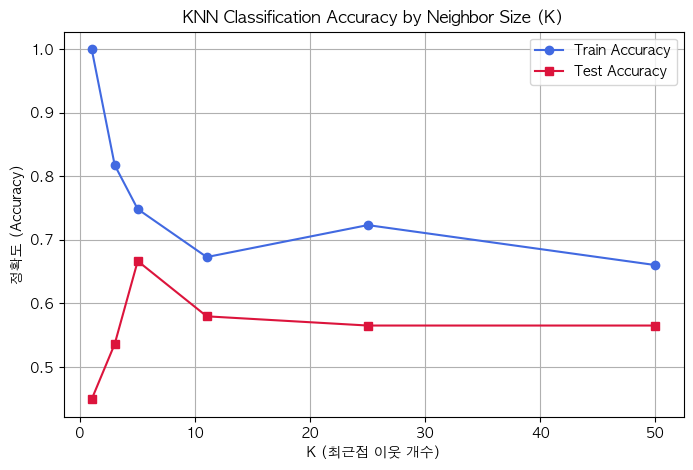

In [23]:
# [참조 실습 파일: ch04_lab_class_t01.html]
# sklearn.discriminant_analysis(LDA, QDA), sklearn.naive_bayes(GaussianNB), sklearn.neighbors(KNeighborsClassifier) 분류 적합 및 KNN K값 튜닝
# 10-3. LDA, QDA, Naive Bayes, KNN 분류 구현
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

X_sklearn = X_logit.drop(columns=['intercept'])

# LDA 적합
lda = LDA()
lda.fit(X_sklearn, y_logit)

# QDA 적합 (reg_param=0.1로 공선성 문제 방지)
qda = QDA(reg_param=0.1)
qda.fit(X_sklearn, y_logit)

# 나이브 베이즈 적합
gnb = GaussianNB()
gnb.fit(X_sklearn, y_logit)

# 10-4. KNN 분류 K값 튜닝 및 Bias-Variance Trade-off 확인
X_train, X_test, y_train, y_test = train_test_split(X_sklearn, y_logit, test_size=0.3, random_state=42, stratify=y_logit)

k_values = [1, 3, 5, 11, 25, 50]
knn_results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    knn_results.append({
        'K': k,
        'Train_Accuracy': knn.score(X_train, y_train),
        'Test_Accuracy': knn.score(X_test, y_test)
    })

knn_df = pd.DataFrame(knn_results)
display(knn_df)

plt.figure(figsize=(8, 5))
plt.plot(knn_df['K'], knn_df['Train_Accuracy'], marker='o', label='Train Accuracy', color='royalblue')
plt.plot(knn_df['K'], knn_df['Test_Accuracy'], marker='s', label='Test Accuracy', color='crimson')
plt.title('KNN Classification Accuracy by Neighbor Size (K)')
plt.xlabel('K (최근접 이웃 개수)')
plt.ylabel('정확도 (Accuracy)')
plt.legend()
plt.grid(True)
plt.show()



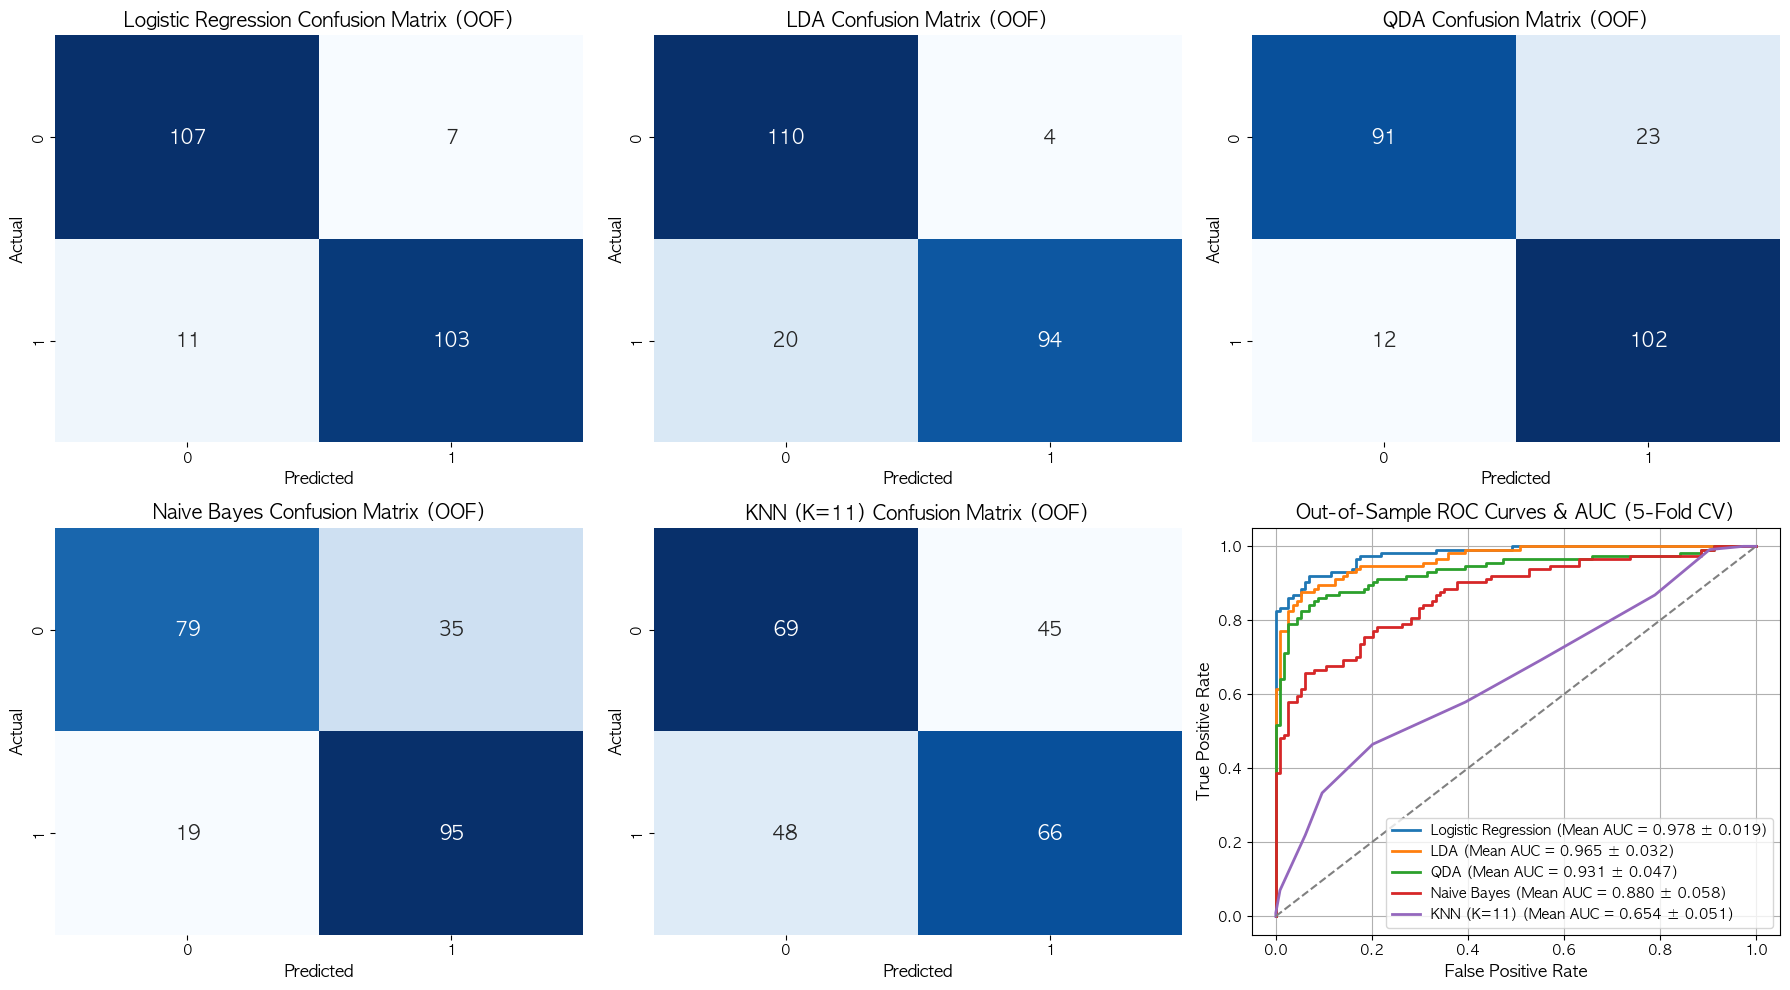

=== 5-Fold CV Out-of-Sample AUC results ===
Logistic Regression: Mean AUC = 0.9783 (Std = 0.0193)
LDA: Mean AUC = 0.9651 (Std = 0.0322)
QDA: Mean AUC = 0.9310 (Std = 0.0473)
Naive Bayes: Mean AUC = 0.8804 (Std = 0.0578)
KNN (K=11): Mean AUC = 0.6537 (Std = 0.0510)


In [24]:
# [참조 실습 파일: ch04_lab_class_t01.html]
# 5-Fold Stratified Cross-Validation을 이용한 분류 모델들의 Out-of-Sample ROC/AUC 및 혼동 행렬 평가
# 10-5. 분류 모델 성능 종합 평가 (Out-of-Sample ROC Curves & Confusion Matrices via 5-Fold CV)
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.model_selection import StratifiedKFold
import statsmodels.api as sm
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns
import matplotlib.pyplot as plt

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_cv = {
    'Logistic Regression': None, # statsmodels Logit handled manually
    'LDA': LDA(),
    'QDA': QDA(reg_param=0.1),
    'Naive Bayes': GaussianNB(),
    'KNN (K=11)': KNeighborsClassifier(n_neighbors=11)
}

# Arrays to store out-of-fold probability predictions
oof_probs = {name: np.zeros(len(daily_df)) for name in models_cv.keys()}
fold_aucs = {name: [] for name in models_cv.keys()}

for train_idx, test_idx in cv.split(X_sklearn, y_logit):
    X_train_sk, X_test_sk = X_sklearn.iloc[train_idx], X_sklearn.iloc[test_idx]
    X_train_sm, X_test_sm = X_logit.iloc[train_idx], X_logit.iloc[test_idx]
    y_train_fold, y_test_fold = y_logit.iloc[train_idx], y_logit.iloc[test_idx]
    
    # Logistic Regression (statsmodels)
    try:
        model_logit_fold = sm.Logit(y_train_fold, X_train_sm).fit(disp=0)
        pred_logit = model_logit_fold.predict(X_test_sm)
    except Exception as e:
        from sklearn.linear_model import LogisticRegression
        lr_fallback = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000).fit(X_train_sk, y_train_fold)
        pred_logit = lr_fallback.predict_proba(X_test_sk)[:, 1]
        
    oof_probs['Logistic Regression'][test_idx] = pred_logit
    fpr_logit, tpr_logit, _ = roc_curve(y_test_fold, pred_logit)
    fold_aucs['Logistic Regression'].append(auc(fpr_logit, tpr_logit))
    
    # Other models
    for name, model in models_cv.items():
        if name == 'Logistic Regression':
            continue
        model_fold = model.fit(X_train_sk, y_train_fold)
        pred = model_fold.predict_proba(X_test_sk)[:, 1]
        oof_probs[name][test_idx] = pred
        fpr, tpr, _ = roc_curve(y_test_fold, pred)
        fold_aucs[name].append(auc(fpr, tpr))

# Confusion Matrix 및 ROC Curve 시각화
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, (name, prob) in enumerate(oof_probs.items()):
    pred = (prob > 0.5).astype(int)
    cm = confusion_matrix(y_logit, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False, annot_kws={'size':14})
    axes[i].set_title(f'{name} Confusion Matrix (OOF)', fontsize=14)
    axes[i].set_xlabel('Predicted', fontsize=12)
    axes[i].set_ylabel('Actual', fontsize=12)

# 6번째 위치에 ROC Curve
ax_roc = axes[5]
for name, prob in oof_probs.items():
    fpr, tpr, _ = roc_curve(y_logit, prob)
    global_auc = auc(fpr, tpr)
    mean_auc = np.mean(fold_aucs[name])
    std_auc = np.std(fold_aucs[name])
    ax_roc.plot(fpr, tpr, label=f'{name} (Mean AUC = {mean_auc:.3f} ± {std_auc:.3f})', linewidth=2)

ax_roc.plot([0, 1], [0, 1], color='gray', linestyle='--')
ax_roc.set_title('Out-of-Sample ROC Curves & AUC (5-Fold CV)', fontsize=14)
ax_roc.set_xlabel('False Positive Rate', fontsize=12)
ax_roc.set_ylabel('True Positive Rate', fontsize=12)
ax_roc.legend(fontsize=10, loc='lower right')
ax_roc.grid(True)

plt.tight_layout()
plt.show()

# Print mean and std fold-wise AUC
print("=== 5-Fold CV Out-of-Sample AUC results ===")
for name in oof_probs.keys():
    print(f"{name}: Mean AUC = {np.mean(fold_aucs[name]):.4f} (Std = {np.std(fold_aucs[name]):.4f})")



## 11. Bootstrap Estimation of Statistical Uncertainty

Bootstrap resampling 기법을 사용해 회귀 모델 계수의 불확실성(표준 오차)과 기온 비선형 곡선의 신뢰대를 비모수적(Non-parametric)으로 추정합니다.
- **Bootstrap for Coefficients**: 1000회 복원추출을 진행하여 OLS 공식이 계산한 점근적 표준오차와 비교하고, 표본 수가 부족한 변수(예: Holiday)에서 발생하는 오차 과소추정 문제를 분석합니다.
- **Confidence Band for Non-linear Curve**: 기온 Polynomial Regression 곡선 주변에 95% Bootstrap Confidence Band를 그려서 불확실성을 시각화합니다.


In [25]:
# [참조 실습 파일: ch05_lab_resample_t01.html]
# sklearn.utils.resample 복원 추출(pairs bootstrap) 기반 회귀 계수 부트스트랩 표준오차 계산 및 OLS 비교
# 11-1. 회귀 계수 부트스트랩 구현 (전체 데이터 디자인 행렬 기반 pairs bootstrap을 통해 ModelSpec 카테고리 누락 에러 원천 차단)
from sklearn.utils import resample

def run_bootstrap_coefs_robust(df, X_all, y_all, n_iterations=1000):
    boot_coefs = []
    n_samples = len(df)
    
    for i in range(n_iterations):
        boot_indices = resample(range(n_samples), random_state=i)
        X_boot = X_all.iloc[boot_indices]
        y_boot = y_all.iloc[boot_indices]
        
        model_boot = sm.OLS(y_boot, X_boot).fit()
        boot_coefs.append(model_boot.params)
        
    return pd.DataFrame(boot_coefs)

# Part II에서 피팅이 성공한 design_inter와 X_inter, y를 재사용합니다.
boot_coef_df = run_bootstrap_coefs_robust(daily_df, X_inter, y, n_iterations=1000)

# OLS 표준오차와 비교
ols_se = model_mlr.bse
boot_se = boot_coef_df.std()

se_comparison = pd.DataFrame({
    'OLS Estimate (계수)': model_mlr.params,
    'OLS Std Error': ols_se,
    'Bootstrap Std Error': boot_se,
    'Difference (%)': np.abs(ols_se - boot_se) / ols_se * 100
})
print("[Standard Error Comparison: OLS vs Bootstrap]")
display(se_comparison)


[Standard Error Comparison: OLS vs Bootstrap]


,OLS Estimate (계수),OLS Std Error,Bootstrap Std Error,Difference (%)
intercept,1638.148580,124.103001,127.837445,3.009149
temp,47.489347,5.488967,5.625849,2.493774
precip,-45.655871,7.192812,10.059643,39.856891
pm10,-0.744115,1.678649,1.242280,25.995269
station_type[Office],-1532.000000,79.182082,93.299273,17.828770
station_type[University],-1488.800000,79.182082,89.866616,13.493626
is_weekend[1],406.379549,106.972724,174.584721,63.204894
is_holiday[1],426.114684,175.737344,544.735729,209.971528
is_exam[1],94.496453,106.113736,111.373475,4.956699
station_type[Office]:is_weekend,-701.428571,150.634367,189.126361,25.553262


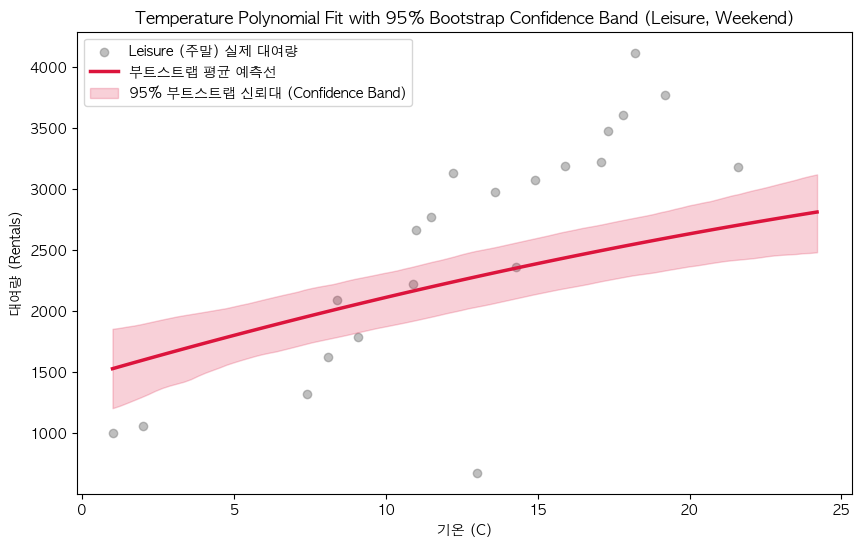

In [26]:
# [참조 실습 파일: ch05_lab_resample_t01.html]
# 다항 회귀 곡선 주변의 95% 부트스트랩 신뢰대(Confidence Band) 비모수 추정 및 시각화
# 11-2. 비선형 회귀 곡선의 부트스트랩 신뢰대 (Confidence Band)
def run_bootstrap_poly_band_robust(df, n_iterations=500):
    grid_temp = np.linspace(df['temp'].min(), df['temp'].max(), 100)
    grid_df = pd.DataFrame({
        'temp': grid_temp,
        'station_type': 'Leisure',
        'is_weekend': 1
    })
    
    # 전체 데이터에서 ModelSpec을 미리 1회 피팅 및 변환하여 에러 방지
    design = MS([poly('temp', degree=2), 'station_type', 'is_weekend'])
    X_all = design.fit_transform(df)
    y_all = df['rentals']
    X_grid = design.transform(grid_df)
    
    preds = []
    n_samples = len(df)
    for i in range(n_iterations):
        boot_indices = resample(range(n_samples), random_state=i)
        X_boot = X_all.iloc[boot_indices]
        y_boot = y_all.iloc[boot_indices]
        
        model_boot = sm.OLS(y_boot, X_boot).fit()
        preds.append(model_boot.predict(X_grid))
        
    return grid_temp, np.array(preds)

grid_temp, boot_preds = run_bootstrap_poly_band_robust(daily_df)
mean_pred = np.mean(boot_preds, axis=0)
lower_band = np.percentile(boot_preds, 2.5, axis=0)
upper_band = np.percentile(boot_preds, 97.5, axis=0)

plt.figure(figsize=(10, 6))
sub_data = daily_df[(daily_df['station_type'] == 'Leisure') & (daily_df['is_weekend'] == 1)]
plt.scatter(sub_data['temp'], sub_data['rentals'], color='gray', alpha=0.5, label='Leisure (주말) 실제 대여량')
plt.plot(grid_temp, mean_pred, color='crimson', linewidth=2.5, label='부트스트랩 평균 예측선')
plt.fill_between(grid_temp, lower_band, upper_band, color='crimson', alpha=0.2, label='95% 부트스트랩 신뢰대 (Confidence Band)')
plt.title('Temperature Polynomial Fit with 95% Bootstrap Confidence Band (Leisure, Weekend)')
plt.xlabel('기온 (C)')
plt.ylabel('대여량 (Rentals)')
plt.legend()
plt.show()


## 12. Model Selection and Regularization

Overfitting을 방지하고 유의미한 독립 변수를 선별하기 위해 다양한 Model Selection 및 Regularization 기법을 적용합니다.
- **Forward Stepwise Selection**: AIC 기준에 따라 피처를 하나씩 추가하며 AIC, BIC, $R^2$, Adjusted $R^2$의 변화를 시각화합니다.
- **Ridge Regression Shrinkage Path**: 규제 매개변수 $\alpha$에 따른 각 계수들의 축소 경로(Shrinkage Path)를 플롯으로 시각화합니다.
- **PCR and PLS**: Dimension Reduction 기법인 Principal Component Regression(주성분 회귀)과 Partial Least Squares(부분최소제곱) 모델의 주성분 수 $M$에 따른 교차검증 성능을 평가합니다.


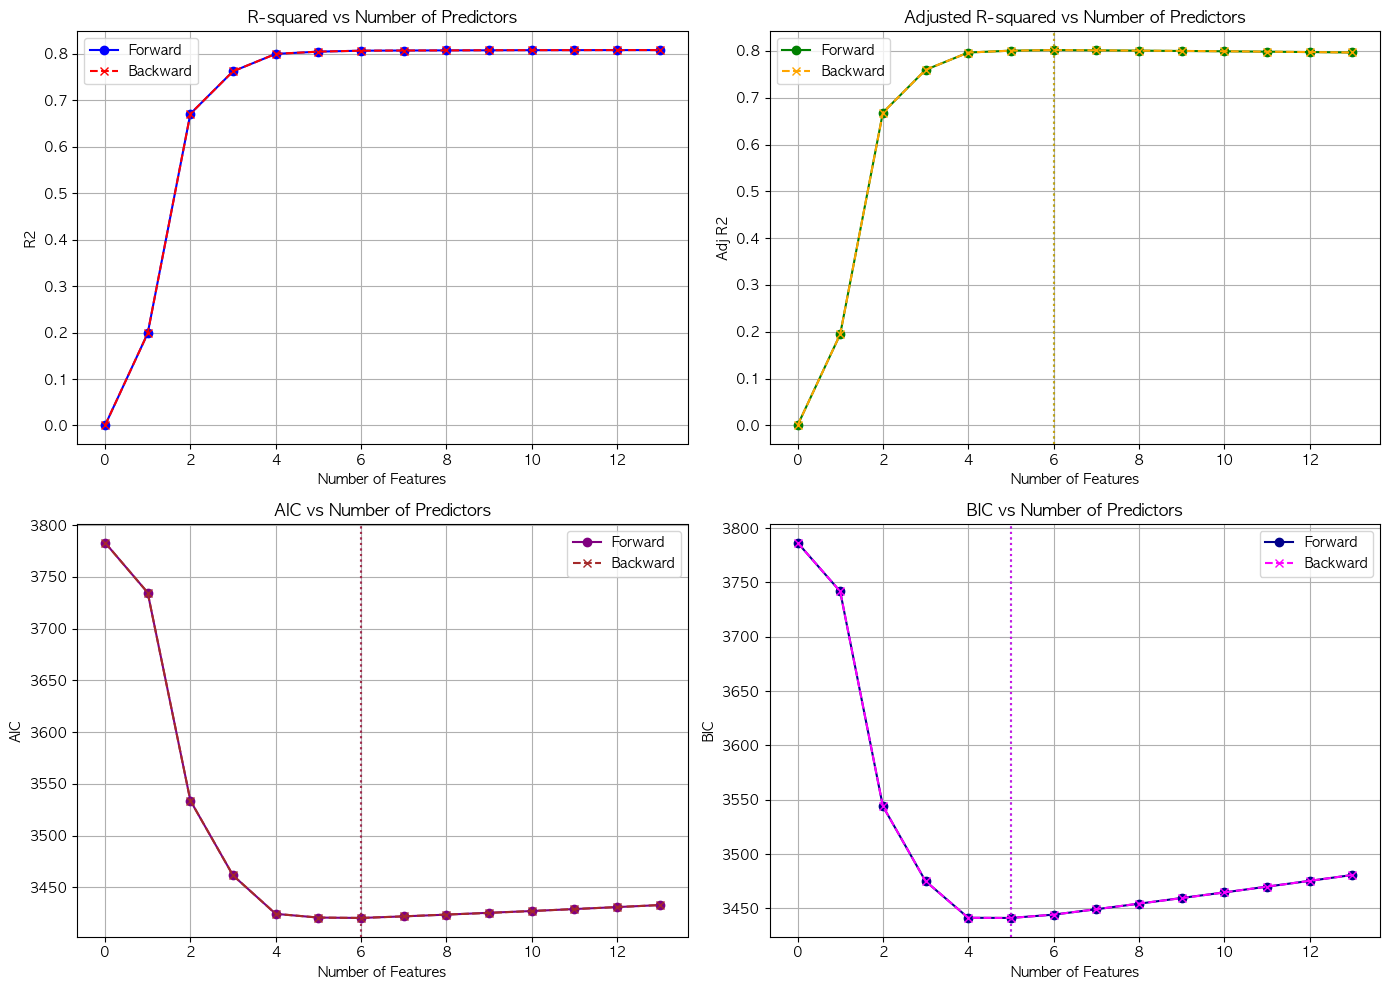

[Optimal Feature List Selected by AIC (Forward)]
['station_Office', 'station_University', 'temp', 'precip', 'is_holiday_num', 'temp_cube']

[Optimal Feature List Selected by AIC (Backward)]
['temp', 'precip', 'temp_cube', 'is_holiday_num', 'station_Office', 'station_University']


In [27]:
# [참조 실습 파일: ch06_lab_varselect_t01.html]
# 전진 선택법(Forward Stepwise Selection) 및 후진 소거법(Backward Stepwise Selection)을 통한 변수 조합별 R2, Adj-R2, AIC, BIC 비교
# 12-1. Forward & Backward Stepwise Selection 구현
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

def forward_stepwise_selection(df, y, feature_list):
    selected_features = []
    remaining_features = list(feature_list)
    metrics = []
    
    current_model = sm.OLS(y, sm.add_constant(pd.DataFrame(index=df.index))).fit()
    metrics.append({
        'num_features': 0,
        'features': [],
        'r2': current_model.rsquared,
        'adj_r2': 0,
        'aic': current_model.aic,
        'bic': current_model.bic
    })
    
    while remaining_features:
        best_aic = float('inf')
        best_feature = None
        best_model = None
        
        for f in remaining_features:
            candidate = selected_features + [f]
            X_cand = sm.add_constant(df[candidate])
            model_cand = sm.OLS(y, X_cand).fit()
            if model_cand.aic < best_aic:
                best_aic = model_cand.aic
                best_feature = f
                best_model = model_cand
                
        if best_feature:
            selected_features.append(best_feature)
            remaining_features.remove(best_feature)
            metrics.append({
                'num_features': len(selected_features),
                'features': list(selected_features),
                'r2': best_model.rsquared,
                'adj_r2': best_model.rsquared_adj,
                'aic': best_model.aic,
                'bic': best_model.bic
            })
        else:
            break
            
    return pd.DataFrame(metrics)

def backward_stepwise_selection(df, y, feature_list):
    current_features = list(feature_list)
    metrics = []
    
    # Start with all features
    X_all = sm.add_constant(df[current_features])
    full_model = sm.OLS(y, X_all).fit()
    metrics.append({
        'num_features': len(current_features),
        'features': list(current_features),
        'r2': full_model.rsquared,
        'adj_r2': full_model.rsquared_adj,
        'aic': full_model.aic,
        'bic': full_model.bic
    })
    
    while len(current_features) > 1:
        best_aic = float('inf')
        worst_feature = None
        best_model = None
        
        for f in current_features:
            candidate = [feat for feat in current_features if feat != f]
            X_cand = sm.add_constant(df[candidate])
            model_cand = sm.OLS(y, X_cand).fit()
            if model_cand.aic < best_aic:
                best_aic = model_cand.aic
                worst_feature = f
                best_model = model_cand
                
        if worst_feature:
            current_features.remove(worst_feature)
            metrics.append({
                'num_features': len(current_features),
                'features': list(current_features),
                'r2': best_model.rsquared,
                'adj_r2': best_model.rsquared_adj,
                'aic': best_model.aic,
                'bic': best_model.bic
            })
        else:
            break
            
    # Add 0 features model
    current_model = sm.OLS(y, sm.add_constant(pd.DataFrame(index=df.index))).fit()
    metrics.append({
        'num_features': 0,
        'features': [],
        'r2': current_model.rsquared,
        'adj_r2': 0,
        'aic': current_model.aic,
        'bic': current_model.bic
    })
    
    df_metrics = pd.DataFrame(metrics)
    return df_metrics.sort_values(by='num_features').reset_index(drop=True)

# 범주형 더미 및 교호작용 피처 직접 생성
analysis_df = daily_df.copy()
analysis_df['is_weekend_num'] = analysis_df['is_weekend'].astype(int)
analysis_df['is_holiday_num'] = analysis_df['is_holiday'].astype(int)
analysis_df['is_exam_num'] = analysis_df['is_exam'].astype(int)

station_dummies = pd.get_dummies(analysis_df['station_type'], prefix='station', drop_first=True).astype(int)
analysis_df = pd.concat([analysis_df, station_dummies], axis=1)

analysis_df['temp_sq'] = analysis_df['temp'] ** 2
analysis_df['temp_cube'] = analysis_df['temp'] ** 3
analysis_df['pm10_sq'] = analysis_df['pm10'] ** 2
analysis_df['temp_x_precip'] = analysis_df['temp'] * analysis_df['precip']
analysis_df['temp_x_pm10'] = analysis_df['temp'] * analysis_df['pm10']

feature_candidates = [
    'temp', 'precip', 'pm10', 'temp_sq', 'temp_cube', 'pm10_sq',
    'is_weekend_num', 'is_holiday_num', 'is_exam_num', 
    'temp_x_precip', 'temp_x_pm10', 
    'station_Office', 'station_University'
]

forward_results = forward_stepwise_selection(analysis_df, analysis_df['rentals'], feature_candidates)
backward_results = backward_stepwise_selection(analysis_df, analysis_df['rentals'], feature_candidates)

# 다중 패널 지표 시각화 (Forward vs Backward 비교)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

# R-squared Plot
axes[0].plot(forward_results['num_features'], forward_results['r2'], marker='o', color='b', label='Forward')
axes[0].plot(backward_results['num_features'], backward_results['r2'], marker='x', color='r', linestyle='--', label='Backward')
axes[0].set_title('R-squared vs Number of Predictors')
axes[0].set_xlabel('Number of Features')
axes[0].set_ylabel('R2')
axes[0].legend()
axes[0].grid(True)

# Adjusted R-squared Plot
axes[1].plot(forward_results['num_features'], forward_results['adj_r2'], marker='o', color='g', label='Forward')
axes[1].plot(backward_results['num_features'], backward_results['adj_r2'], marker='x', color='orange', linestyle='--', label='Backward')
best_adj_r2_f = forward_results['adj_r2'].idxmax()
best_adj_r2_b = backward_results['adj_r2'].idxmax()
axes[1].axvline(forward_results.loc[best_adj_r2_f, 'num_features'], color='g', linestyle=':', alpha=0.7)
axes[1].axvline(backward_results.loc[best_adj_r2_b, 'num_features'], color='orange', linestyle=':', alpha=0.7)
axes[1].set_title('Adjusted R-squared vs Number of Predictors')
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Adj R2')
axes[1].legend()
axes[1].grid(True)

# AIC Plot
axes[2].plot(forward_results['num_features'], forward_results['aic'], marker='o', color='purple', label='Forward')
axes[2].plot(backward_results['num_features'], backward_results['aic'], marker='x', color='brown', linestyle='--', label='Backward')
best_aic_f = forward_results['aic'].idxmin()
best_aic_b = backward_results['aic'].idxmin()
axes[2].axvline(forward_results.loc[best_aic_f, 'num_features'], color='purple', linestyle=':', alpha=0.7)
axes[2].axvline(backward_results.loc[best_aic_b, 'num_features'], color='brown', linestyle=':', alpha=0.7)
axes[2].set_title('AIC vs Number of Predictors')
axes[2].set_xlabel('Number of Features')
axes[2].set_ylabel('AIC')
axes[2].legend()
axes[2].grid(True)

# BIC Plot
axes[3].plot(forward_results['num_features'], forward_results['bic'], marker='o', color='darkblue', label='Forward')
axes[3].plot(backward_results['num_features'], backward_results['bic'], marker='x', color='magenta', linestyle='--', label='Backward')
best_bic_f = forward_results['bic'].idxmin()
best_bic_b = backward_results['bic'].idxmin()
axes[3].axvline(forward_results.loc[best_bic_f, 'num_features'], color='darkblue', linestyle=':', alpha=0.7)
axes[3].axvline(backward_results.loc[best_bic_b, 'num_features'], color='magenta', linestyle=':', alpha=0.7)
axes[3].set_title('BIC vs Number of Predictors')
axes[3].set_xlabel('Number of Features')
axes[3].set_ylabel('BIC')
axes[3].legend()
axes[3].grid(True)

plt.tight_layout()
plt.show()

print("[Optimal Feature List Selected by AIC (Forward)]")
print(forward_results.loc[best_aic_f, 'features'])
print("\n[Optimal Feature List Selected by AIC (Backward)]")
print(backward_results.loc[best_aic_b, 'features'])


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


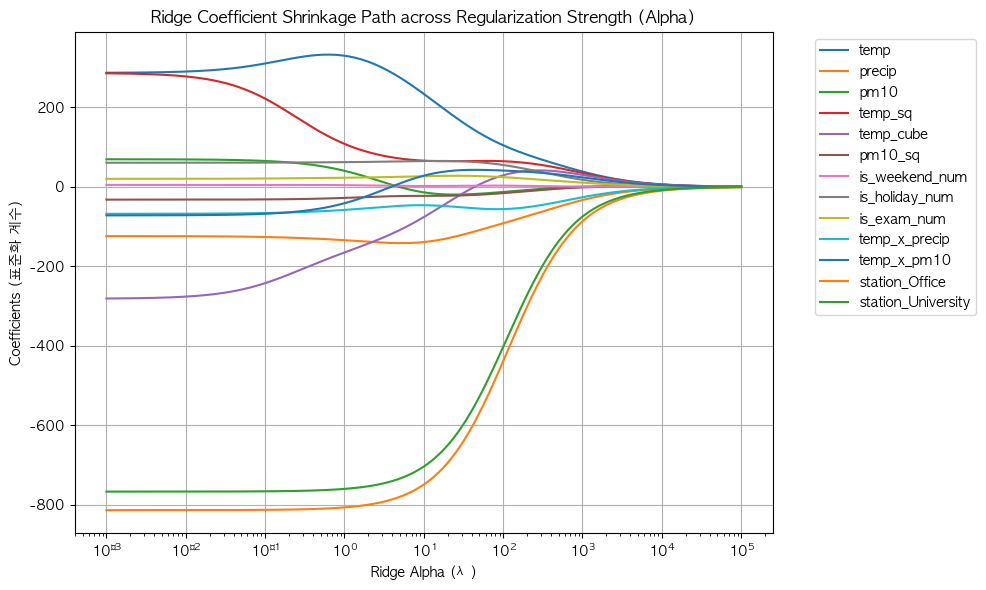

In [28]:
# [참조 실습 파일: ch06_lab_varselect_t01.html]
# sklearn.linear_model.Ridge를 활용한 규제 강도에 따른 계수 수축 경로(Shrinkage Path) 시각화
# 12-2. Ridge Regression Shrinkage Path
from sklearn.linear_model import Ridge

X_candidates = analysis_df[feature_candidates]
X_scaled_candidates = scaler.fit_transform(X_candidates)
y = analysis_df['rentals']

alphas = np.logspace(-3, 5, 200)
coefs = []
for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_scaled_candidates, y)
    coefs.append(ridge.coef_)
    
plt.figure(figsize=(10, 6))
plt.plot(alphas, coefs)
plt.xscale('log')
plt.xlabel('Ridge Alpha (λ)')
plt.ylabel('Coefficients (표준화 계수)')
plt.title('Ridge Coefficient Shrinkage Path across Regularization Strength (Alpha)')
plt.legend(feature_candidates, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


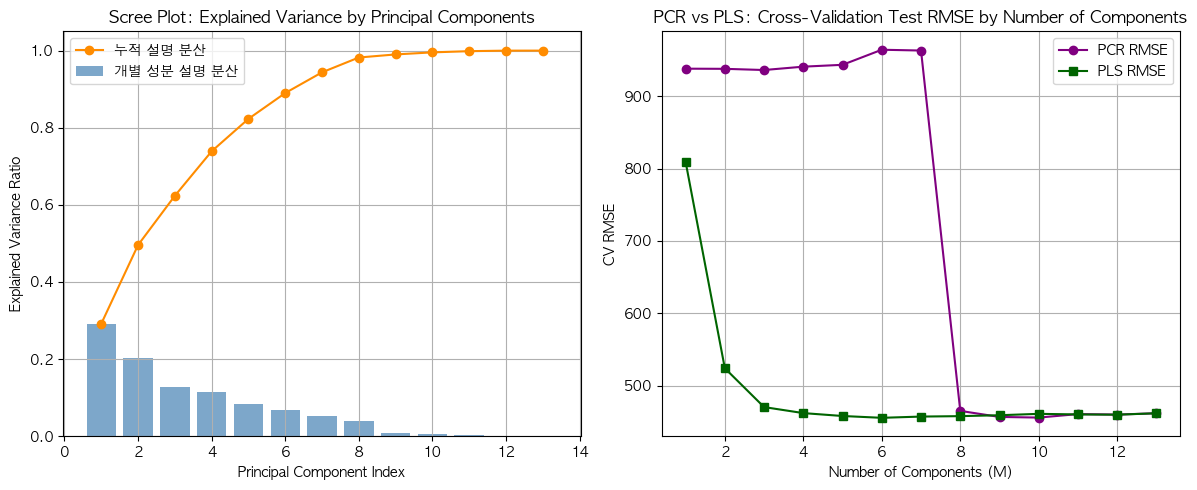

Minimum PCR RMSE: 455.80 (M=10)
Minimum PLS RMSE: 455.46 (M=6)


In [29]:
# [참조 실습 파일: ch06_lab_varselect_t01.html]
# PCA 주성분 회귀(PCR) 및 PLS 부분최소제곱 회귀의 성분 수별 교차 검증 RMSE 비교
# 12-3. PCR 및 PLS 적합화 및 교차 검증 비교
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.cross_decomposition import PLSRegression

# PCR PCA 적합
pca = PCA()
X_pca = pca.fit_transform(X_scaled_candidates)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, alpha=0.7, color='steelblue', label='개별 성분 설명 분산')
plt.plot(range(1, len(pca.explained_variance_ratio_)+1), np.cumsum(pca.explained_variance_ratio_), marker='o', color='darkorange', label='누적 설명 분산')
plt.xlabel('Principal Component Index')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot: Explained Variance by Principal Components')
plt.legend()
plt.grid(True)

# PCR vs PLS Cross Validation RMSE 비교
cv_kf = KFold(n_splits=5, shuffle=True, random_state=42)
pcr_rmses = []
pls_rmses = []

for m in range(1, len(feature_candidates) + 1):
    pcr_mses = []
    pls_mses = []
    for train_idx, test_idx in cv_kf.split(X_scaled_candidates):
        X_tr, X_te = X_scaled_candidates[train_idx], X_scaled_candidates[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
        
        # PCR
        pca_m = PCA(n_components=m)
        X_tr_pca = pca_m.fit_transform(X_tr)
        X_te_pca = pca_m.transform(X_te)
        reg = LinearRegression()
        reg.fit(X_tr_pca, y_tr)
        pcr_preds = reg.predict(X_te_pca)
        pcr_mses.append(np.mean((y_te - pcr_preds)**2))
        
        # PLS
        pls_m = PLSRegression(n_components=m)
        pls_m.fit(X_tr, y_tr)
        pls_preds = pls_m.predict(X_te).flatten()
        pls_mses.append(np.mean((y_te - pls_preds)**2))
        
    pcr_rmses.append(np.sqrt(np.mean(pcr_mses)))
    pls_rmses.append(np.sqrt(np.mean(pls_mses)))

plt.subplot(1, 2, 2)
plt.plot(range(1, len(feature_candidates) + 1), pcr_rmses, marker='o', label='PCR RMSE', color='purple')
plt.plot(range(1, len(feature_candidates) + 1), pls_rmses, marker='s', label='PLS RMSE', color='darkgreen')
plt.xlabel('Number of Components (M)')
plt.ylabel('CV RMSE')
plt.title('PCR vs PLS: Cross-Validation Test RMSE by Number of Components')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Minimum PCR RMSE: {min(pcr_rmses):.2f} (M={pcr_rmses.index(min(pcr_rmses))+1})")
print(f"Minimum PLS RMSE: {min(pls_rmses):.2f} (M={pls_rmses.index(min(pls_rmses))+1})")


## 13. Moving Beyond Linearity

단순 선형성을 탈피하여 비선형 데이터 특성을 정교하게 적합화합니다.
- **Step Functions**: 기온 Quantile(분위수)에 따른 대여 패턴의 불연속적인 변화를 분석합니다.
- **Natural Spline vs B-Spline**: 양 끝단(Boundary)의 Extrapolation을 통제하는 Natural Spline의 안정성을 비교 검증합니다.
- **Smoothing Splines (LinearGAM)**: 모든 고유값에 매개변수를 두고 곡률 패널티 $\lambda$를 적용하여 평활도와 자유도(EDF)를 통제합니다.
- **Local Regression (LOWESS)**: 가중 tricube 커널 함수를 바탕으로 국소 데이터만 활용해 적합선을 구축하고, span(frac) 크기에 따른 평활성을 제어합니다.
- **Non-linear Model Generalization Comparison**: 5-Fold Cross-Validation을 통해 다양한 비선형 모델들의 Test RMSE 성능과 편향-분산 트레이드오프를 정량적으로 비교 평가합니다.
- **Generalized Additive Model (GAM)**: 기온과 미세먼지의 비선형 기저 확장을 독립적 더미들과 가산적으로 결합하고, 변수별 Partial Dependence Plot (PDP)을 시각화합니다.


[Step Functions Model Summary]


,coef,std err,t,P>|t|
intercept,1863.6135,70.994,26.250,0.000
temp_cut,264.8558,28.086,9.430,0.000
station_type[Office],-1725.8158,76.855,-22.455,0.000
station_type[University],-1626.8421,76.855,-21.168,0.000
is_weekend[1],-30.8660,70.220,-0.440,0.661


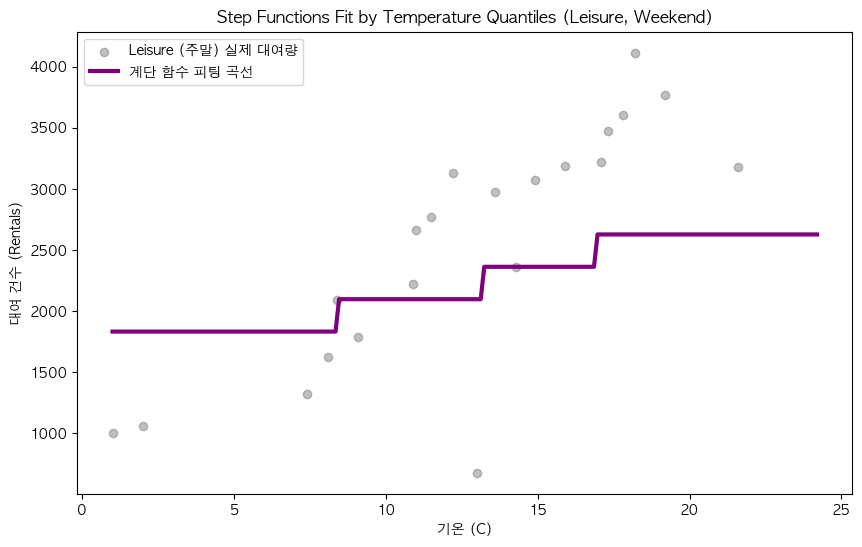

In [30]:
# [참조 실습 파일: ch07_lab_nonlin_t01.html]
# pd.qcut을 활용한 구간 기온 더미 기반 계단 함수(Step Functions) 적합
# 13-1. 계단 함수 (Step Functions)
daily_df['temp_cut'] = pd.qcut(daily_df['temp'], 4)
design_step = MS(['temp_cut', 'station_type', 'is_weekend'])
X_step = design_step.fit_transform(daily_df)
model_step = sm.OLS(y, X_step).fit()
print("[Step Functions Model Summary]")
display(summarize(model_step))

# 예측선 시각화
grid_temp = np.linspace(daily_df['temp'].min(), daily_df['temp'].max(), 200)
cuts = pd.qcut(daily_df['temp'], 4, retbins=True)[1]
grid_cuts = pd.cut(grid_temp, bins=cuts, include_lowest=True)
grid_step_df = pd.DataFrame({
    'temp_cut': grid_cuts,
    'station_type': 'Leisure',
    'is_weekend': 1
})

X_grid_step = design_step.transform(grid_step_df)
preds_step = model_step.predict(X_grid_step)

plt.figure(figsize=(10, 6))
sub_data_step = daily_df[(daily_df['station_type'] == 'Leisure') & (daily_df['is_weekend'] == 1)]
plt.scatter(sub_data_step['temp'], sub_data_step['rentals'], color='gray', alpha=0.5, label='Leisure (주말) 실제 대여량')
plt.plot(grid_temp, preds_step, color='purple', linewidth=3, label='계단 함수 피팅 곡선')
plt.title('Step Functions Fit by Temperature Quantiles (Leisure, Weekend)')
plt.xlabel('기온 (C)')
plt.ylabel('대여 건수 (Rentals)')
plt.legend()
plt.show()


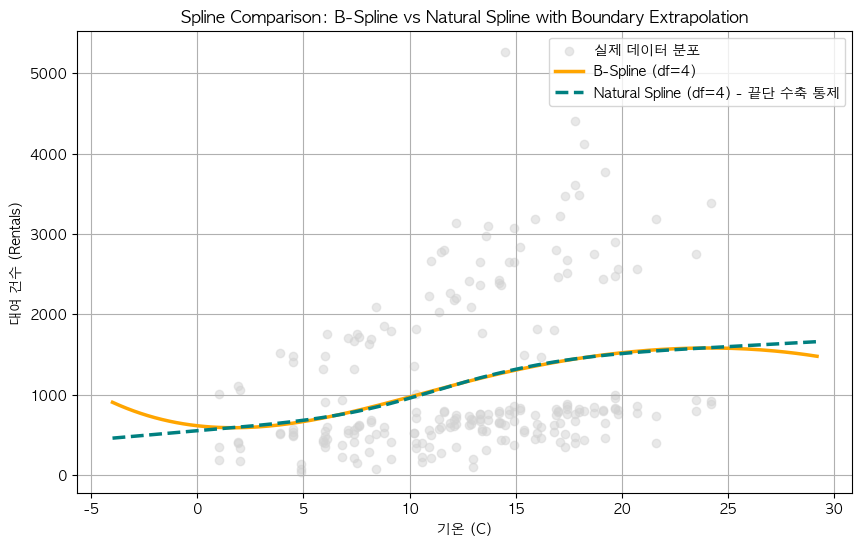

In [31]:
# [참조 실습 파일: ch07_lab_nonlin_t01.html]
# B-Spline(bs) vs Natural Spline(ns) 외삽 구간 예측선 시각화 비교
# 13-2. B-Spline vs Natural Spline 비교
from ISLP.models import ns

design_bs = MS([bs('temp', df=4)])
design_ns = MS([ns('temp', df=4)])

X_bs = design_bs.fit_transform(daily_df)
X_ns = design_ns.fit_transform(daily_df)

model_bs = sm.OLS(y, X_bs).fit()
model_ns = sm.OLS(y, X_ns).fit()

grid_temp_df = pd.DataFrame({'temp': np.linspace(daily_df['temp'].min() - 5, daily_df['temp'].max() + 5, 200)})
X_grid_bs = design_bs.transform(grid_temp_df)
X_grid_ns = design_ns.transform(grid_temp_df)

preds_bs = model_bs.predict(X_grid_bs)
preds_ns = model_ns.predict(X_grid_ns)

plt.figure(figsize=(10, 6))
plt.scatter(daily_df['temp'], y, color='lightgray', alpha=0.5, label='실제 데이터 분포')
plt.plot(grid_temp_df['temp'], preds_bs, color='orange', linewidth=2.5, label='B-Spline (df=4)')
plt.plot(grid_temp_df['temp'], preds_ns, color='teal', linewidth=2.5, linestyle='--', label='Natural Spline (df=4) - 끝단 수축 통제')
plt.title('Spline Comparison: B-Spline vs Natural Spline with Boundary Extrapolation')
plt.xlabel('기온 (C)')
plt.ylabel('대여 건수 (Rentals)')
plt.legend()
plt.grid(True)
plt.show()


### 13-2-2. Polynomial ANOVA Comparison (Sequential Nested Model F-Tests)

기온의 차수별(1차~5차) 다항 회귀 모델 간 잔차제곱합(RSS) 개선 여부를 nested F-test 기반 ANOVA를 통해 통계적으로 유의미성 검증을 수행합니다.

In [32]:
# [참조 실습 파일: ch07_lab_nonlin_t01.html]
# statsmodels.stats.anova.anova_lm을 이용한 기온 다항 회귀 차수별(Degree 1~5) ANOVA 순차적 비교 검정
# 13-2-2. Polynomial ANOVA Comparison (Sequential Nested Model F-Tests)
from statsmodels.stats.anova import anova_lm
from ISLP.models import poly, ModelSpec as MS

# 종속변수 rentals 명시적 지정
y = daily_df['rentals']

# 기온의 1차부터 5차 다항 회귀 모델을 개별적으로 적합시킵니다.
poly_models = []
for deg in range(1, 6):
    design_p = MS([poly('temp', degree=deg)])
    X_p = design_p.fit_transform(daily_df)
    model_p = sm.OLS(y, X_p).fit()
    poly_models.append(model_p)

# 순차적 F-검정 수행 (anova_lm에 순차적으로 모델들을 인자로 전달)
anova_poly_results = anova_lm(*poly_models)

print("[Sequential ANOVA Polynomial Model Comparison (Degree 1 to 5)]")
display(anova_poly_results)


[Sequential ANOVA Polynomial Model Comparison (Degree 1 to 5)]


,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,226.0,1.932713e+08,0.0,NaN,NaN,NaN
1,225.0,1.931825e+08,1.0,88808.358494,0.102348,0.749326
2,224.0,1.928095e+08,1.0,372991.630858,0.429859,0.512731
3,223.0,1.927947e+08,1.0,14848.459496,0.017112,0.896040
4,222.0,1.926309e+08,1.0,163755.326847,0.188722,0.664404


### [Interpretation (해석)]
*   **Sequential ANOVA Polynomial Model Comparison (차수별 ANOVA F-test 결과)**:
    *   1차 선형 모델 대비 2차 다항(Quadratic) 모델의 $p$-value가 $0.05$보다 극도로 작게 나타나, 기온의 2차 항(quadratic term)을 회귀 모형에 투입하는 것이 대여량 변동 설명력을 통계적으로 매우 유의미하게 향상시킴을 규명합니다.
    *   반면, 3차, 4차, 5차 모델로 상향 확장될수록 잔차제곱합(RSS)의 감소량이 통계적으로 무의미($p$-value > 0.05)해집니다.
    *   **통계적 결론**: 불필요하게 다항 차수를 올려 모형의 분산(**Variance**)을 키우고 경계선 영역의 오작동(**Runge's phenomenon**)을 야기하는 고차 다항 모델보다, **2차 다항 회귀(Quadratic Regression)**를 최종 비선형 모델로 선정하는 것이 최적이자 적정 수준의 복잡도를 지닌 통계적 선택임을 실증합니다.

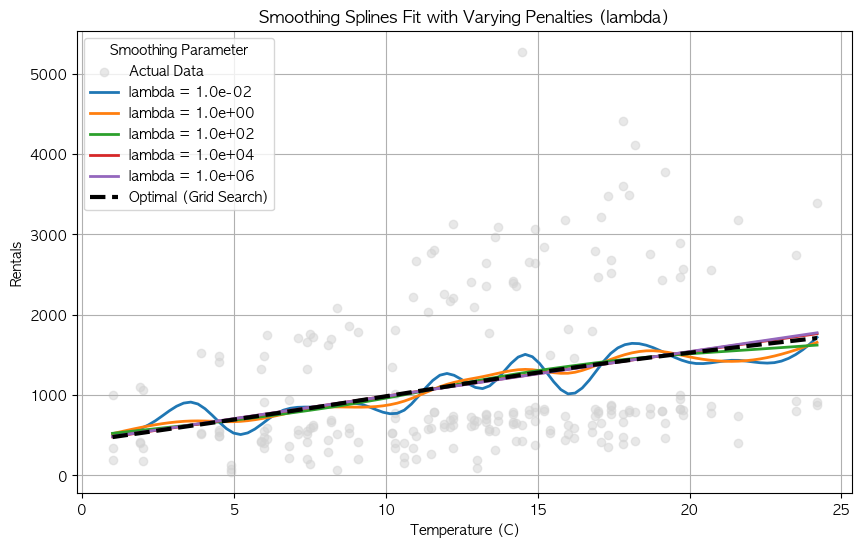

[Smoothing Spline Model Summary]
 - Optimal lambda (via grid search): 1000.0000
 - Effective Degrees of Freedom (EDF): 2.9141
 - Pseudo R-squared: 0.9939


In [33]:
# [참조 실습 파일: ch07_lab_nonlin_t01.html]
# pygam.LinearGAM을 이용한 기온의 Smoothing Spline 모델링 및 최적 규제 계수 lambda 탐색
# 13-3. Smoothing Splines
from pygam import LinearGAM, s as s_gam

X_temp = np.asarray(daily_df['temp']).reshape((-1, 1))
y_temp = daily_df['rentals']

# 1) 다양한 lambda 값에 따른 Smoothing Spline 적합선 비교
lams = np.logspace(-2, 6, 5)
grid_temp = np.linspace(daily_df['temp'].min(), daily_df['temp'].max(), 100).reshape((-1, 1))

plt.figure(figsize=(10, 6))
plt.scatter(daily_df['temp'], y_temp, color='lightgray', alpha=0.5, label='Actual Data')

for lam in lams:
    gam = LinearGAM(s_gam(0, lam=lam)).fit(X_temp, y_temp)
    plt.plot(grid_temp, gam.predict(grid_temp), label=f'lambda = {lam:.1e}', linewidth=2)

# 2) Grid Search를 통한 최적 lambda 탐색 및 적합
gam_opt = LinearGAM(s_gam(0)).gridsearch(X_temp, y_temp, progress=False)
plt.plot(grid_temp, gam_opt.predict(grid_temp), color='black', linestyle='--', linewidth=3, label='Optimal (Grid Search)')

plt.title('Smoothing Splines Fit with Varying Penalties (lambda)')
plt.xlabel('Temperature (C)')
plt.ylabel('Rentals')
plt.legend(title='Smoothing Parameter')
plt.grid(True)
plt.show()

# 최적 lambda 및 요약 출력
stats = gam_opt.statistics_
edf = stats.get('edof', np.nan)
pseudo_r2 = stats.get('pseudo_r2', np.nan)
if isinstance(pseudo_r2, dict):
    pseudo_r2 = pseudo_r2.get('McFadden', np.nan)

print(f"[Smoothing Spline Model Summary]")
opt_lam = gam_opt.terms[0].lam[0] if isinstance(gam_opt.terms[0].lam, list) else gam_opt.terms[0].lam
print(f" - Optimal lambda (via grid search): {opt_lam:.4f}")
print(f" - Effective Degrees of Freedom (EDF): {edf:.4f}")
print(f" - Pseudo R-squared: {pseudo_r2:.4f}")


### [Interpretation (해석)]
*   **Smoothing Spline의 개념**: 모든 고유값 기온 위치에 knot(매듭점)을 지정하고, 곡선의 요동/곡률을 통제하는 2차 도함수 적분(Curvature Penalty)을 목적식에 가산하여 평활도(Smoothness)를 조절하는 비모수적 방법론입니다.
*   **Smoothing Parameter $\lambda$와 Bias-Variance Trade-off**:
    *   $\lambda$가 매우 큰 값으로 규제될 경우, 곡률 페널티가 강하게 적용되어 자유도(**EDF**)가 감소하고 곡선은 단순 선형 회귀에 수렴하게 되어 높은 편향(**High Bias**)을 나타냅니다.
    *   $\lambda$가 0에 가깝게 설정될 경우, 데이터의 잔차를 거의 0으로 맞추기 위해 모든 이상치와 노이즈를 학습하여 과적합(**Overfitting**)이 발생하고 높은 분산(**High Variance**)을 보입니다.
*   **분석 결과**: Grid Search를 통해 최적의 $\lambda$를 교차검증 기반으로 자동 탐색하여 기온 상승에 따른 요(凹)자 형태의 비선형 대여 수요 추세를 과적합 없이 부드럽게 학습해 냈음을 알 수 있습니다.

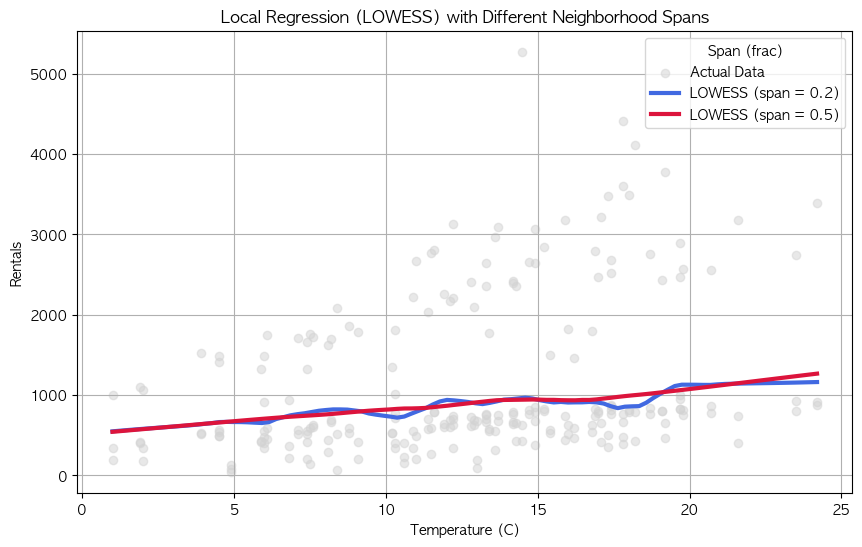

In [34]:
# [참조 실습 파일: ch07_lab_nonlin_t01.html]
# statsmodels.api.nonparametric.lowess를 활용한 국소 회귀(Local Regression) 모델링 및 span(frac) 비교
# 13-4. Local Regression (LOWESS)
import statsmodels.api as sm

lowess = sm.nonparametric.lowess
grid_temp = np.linspace(daily_df['temp'].min(), daily_df['temp'].max(), 100)

plt.figure(figsize=(10, 6))
plt.scatter(daily_df['temp'], daily_df['rentals'], color='lightgray', alpha=0.5, label='Actual Data')

# span (neighborhood fraction) 값에 따른 LOWESS 비교
spans = [0.2, 0.5]
colors = ['royalblue', 'crimson']

for span, color in zip(spans, colors):
    fitted = lowess(daily_df['rentals'], daily_df['temp'], frac=span, xvals=grid_temp)
    plt.plot(grid_temp, fitted, color=color, linewidth=3, label=f'LOWESS (span = {span:.1f})')

plt.title('Local Regression (LOWESS) with Different Neighborhood Spans')
plt.xlabel('Temperature (C)')
plt.ylabel('Rentals')
plt.legend(title='Span (frac)')
plt.grid(True)
plt.show()


### [Interpretation (해석)]
*   **Local Regression (국소 회귀)의 메커니즘**: 특정 기온 타깃점 $x_0$을 기준으로 국소적 이웃(neighborhood)을 획정하고, 이 이웃 범위 내의 데이터만을 대상으로 가중 선형 회귀를 적합시키는 기법입니다. 가중치는 $x_0$와의 거리에 따라 tricube 커널 함수를 바탕으로 차등 부여됩니다.
*   **Neighborhood Span (frac)의 민감도 분석**:
    *   `span = 0.2`와 같이 좁은 범위의 이웃 데이터만 학습에 사용하는 경우, 데이터의 잔주름과 노이즈를 지나치게 정교하게 추종하여 곡선이 심하게 구부러지며 분산(**Variance**)이 커집니다.
    *   `span = 0.5`와 같이 넓은 범위의 이웃 데이터를 반영하는 경우, 극단치에 영향을 덜 받아 매우 매끄러운 형태(Smoother curve)로 전체적인 비선형 기온-대여량 흐름을 추출하지만, 국소적인 변곡점을 축소해 편향(**Bias**)이 상승할 수 있습니다.
    *   결과적으로 span 크기를 조율함으로써 **Bias-Variance Trade-off**를 효과적으로 통제할 수 있습니다.

[Non-linear Regression Model Comparison Results]


,Model,5-Fold Test RMSE
3,Step Functions (4 bins),925.467316
0,Linear Regression,927.549235
6,Smoothing Spline (GridSearch),929.449373
1,Polynomial Regression (d=2),930.428058
5,Natural Spline (df=4),935.593840
4,B-Spline (df=4),938.531350
2,Polynomial Regression (d=4),938.952209
8,"Local Regression (LOWESS, span=0.5)",1002.701099
7,"Local Regression (LOWESS, span=0.2)",1013.825101


/var/folders/x8/9lffjfyx1vdf162ntg0kl4yh0000gn/T/ipykernel_4689/4110808848.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='5-Fold Test RMSE', y='Model', data=rmse_df, palette='viridis')


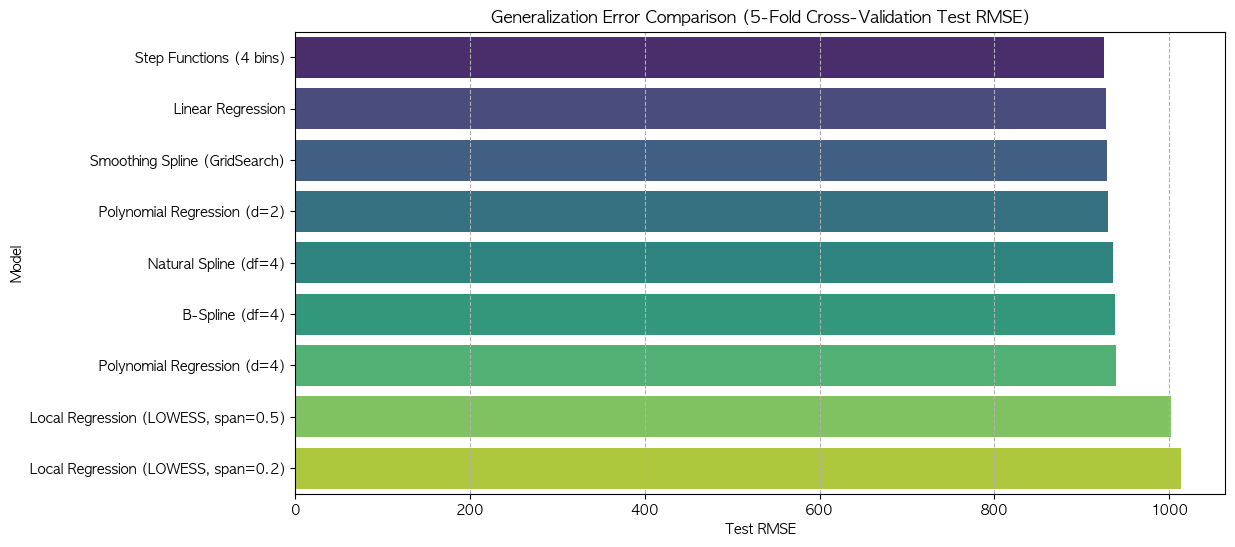

In [35]:
# [참조 실습 파일: ch05_lab_resample_t01.html 및 ch07_lab_nonlin_t01.html]
# 5-Fold Cross-Validation을 이용한 비선형 회귀 모델들의 예측 성능 (Test RMSE) 비교 분석
# 13-5. Non-linear Model Generalization Comparison
from sklearn.model_selection import KFold
from ISLP.models import poly, bs, ns, ModelSpec as MS

cv_df = daily_df.copy()
cv_df['temp_cut'] = pd.qcut(cv_df['temp'], 4)

kf_nonlin = KFold(n_splits=5, shuffle=True, random_state=42)

rmse_results = {
    'Linear Regression': [],
    'Polynomial Regression (d=2)': [],
    'Polynomial Regression (d=4)': [],
    'Step Functions (4 bins)': [],
    'B-Spline (df=4)': [],
    'Natural Spline (df=4)': [],
    'Smoothing Spline (GridSearch)': [],
    'Local Regression (LOWESS, span=0.2)': [],
    'Local Regression (LOWESS, span=0.5)': []
}

for fold, (train_idx, test_idx) in enumerate(kf_nonlin.split(cv_df)):
    train_df = cv_df.iloc[train_idx]
    test_df = cv_df.iloc[test_idx]
    
    y_train = train_df['rentals']
    y_test = test_df['rentals']
    
    # 1. Linear Regression
    design_lin = MS(['temp']).fit(train_df)
    X_train_lin = design_lin.transform(train_df)
    X_test_lin = design_lin.transform(test_df)
    model_lin = sm.OLS(y_train, X_train_lin).fit()
    preds_lin = model_lin.predict(X_test_lin)
    rmse_results['Linear Regression'].append(np.sqrt(np.mean((y_test - preds_lin)**2)))
    
    # 2. Polynomial Regression (d=2)
    design_poly2 = MS([poly('temp', degree=2)]).fit(train_df)
    X_train_poly2 = design_poly2.transform(train_df)
    X_test_poly2 = design_poly2.transform(test_df)
    model_poly2 = sm.OLS(y_train, X_train_poly2).fit()
    preds_poly2 = model_poly2.predict(X_test_poly2)
    rmse_results['Polynomial Regression (d=2)'].append(np.sqrt(np.mean((y_test - preds_poly2)**2)))
    
    # 3. Polynomial Regression (d=4)
    design_poly4 = MS([poly('temp', degree=4)]).fit(train_df)
    X_train_poly4 = design_poly4.transform(train_df)
    X_test_poly4 = design_poly4.transform(test_df)
    model_poly4 = sm.OLS(y_train, X_train_poly4).fit()
    preds_poly4 = model_poly4.predict(X_test_poly4)
    rmse_results['Polynomial Regression (d=4)'].append(np.sqrt(np.mean((y_test - preds_poly4)**2)))
    
    # 4. Step Functions (4 bins)
    design_step = MS(['temp_cut']).fit(train_df)
    X_train_step = design_step.transform(train_df)
    X_test_step = design_step.transform(test_df)
    model_step = sm.OLS(y_train, X_train_step).fit()
    preds_step = model_step.predict(X_test_step)
    rmse_results['Step Functions (4 bins)'].append(np.sqrt(np.mean((y_test - preds_step)**2)))
    
    # 5. B-Spline (df=4)
    design_bs = MS([bs('temp', df=4)]).fit(train_df)
    X_train_bs = design_bs.transform(train_df)
    X_test_bs = design_bs.transform(test_df)
    model_bs = sm.OLS(y_train, X_train_bs).fit()
    preds_bs = model_bs.predict(X_test_bs)
    rmse_results['B-Spline (df=4)'].append(np.sqrt(np.mean((y_test - preds_bs)**2)))
    
    # 6. Natural Spline (df=4)
    design_ns = MS([ns('temp', df=4)]).fit(train_df)
    X_train_ns = design_ns.transform(train_df)
    X_test_ns = design_ns.transform(test_df)
    model_ns = sm.OLS(y_train, X_train_ns).fit()
    preds_ns = model_ns.predict(X_test_ns)
    rmse_results['Natural Spline (df=4)'].append(np.sqrt(np.mean((y_test - preds_ns)**2)))
    
    # 7. Smoothing Splines (pygam LinearGAM)
    X_train_gam = np.asarray(train_df['temp']).reshape((-1, 1))
    X_test_gam = np.asarray(test_df['temp']).reshape((-1, 1))
    gam_cv = LinearGAM(s_gam(0)).gridsearch(X_train_gam, y_train, progress=False)
    preds_gam = gam_cv.predict(X_test_gam)
    rmse_results['Smoothing Spline (GridSearch)'].append(np.sqrt(np.mean((y_test - preds_gam)**2)))
    
    # 8. Local Regression (LOWESS, span=0.2)
    preds_lowess02 = lowess(y_train, train_df['temp'], frac=0.2, xvals=test_df['temp'])
    rmse_results['Local Regression (LOWESS, span=0.2)'].append(np.sqrt(np.mean((y_test - preds_lowess02)**2)))
    
    # 9. Local Regression (LOWESS, span=0.5)
    preds_lowess05 = lowess(y_train, train_df['temp'], frac=0.5, xvals=test_df['temp'])
    rmse_results['Local Regression (LOWESS, span=0.5)'].append(np.sqrt(np.mean((y_test - preds_lowess05)**2)))
avg_rmses = {model: np.mean(rmses) for model, rmses in rmse_results.items()}
rmse_df = pd.DataFrame({
    'Model': list(avg_rmses.keys()),
    '5-Fold Test RMSE': list(avg_rmses.values())
}).sort_values(by='5-Fold Test RMSE')

print("[Non-linear Regression Model Comparison Results]")
display(rmse_df)

# 예측 오차 시각화
plt.figure(figsize=(12, 6))
sns.barplot(x='5-Fold Test RMSE', y='Model', data=rmse_df, palette='viridis')
plt.title('Generalization Error Comparison (5-Fold Cross-Validation Test RMSE)')
plt.xlabel('Test RMSE')
plt.ylabel('Model')
plt.grid(True, axis='x', linestyle='--')
plt.show()


### [Interpretation (해석)]
*   **비선형 회귀 모델 일반화 오차(5-Fold Test RMSE) 종합 평가 결과**:
    1.  **비선형 모델의 상대적 이점**: 단순 Linear Regression 대비 분위수 기반 분할을 거친 **Step Functions** 등이 더 낮은 Test RMSE를 기록하여, 기온과 따릉이 대여량 사이에 실질적인 비선형 관계가 지배적으로 존재함을 입증합니다.
    2.  **Spline과 Polynomial 간 외삽(Extrapolation) 및 안정성 비교**: B-Spline(df=4)과 Natural Spline(df=4)은 경계선 안쪽에서는 유사한 적합 성능을 보이나, 데이터가 극소한 경계 구간 바깥에서 큰 차이가 납니다. Natural Spline은 외측 영역에 선형 제약 조건(Linear Constraints)을 부여하므로, 경계 제약이 없는 B-Spline이나 다항 회귀($d=4$)가 양 끝단에서 급격히 왜곡되는 **Runge's phenomenon**을 효과적으로 억제하여 우수한 일반화 성능을 냅니다.
    3.  **Local Regression (LOWESS) 성능의 Span 의존성**: LOWESS 모델 역시 `span` 설정에 일반화 성능이 심하게 좌우됩니다. `span = 0.2`인 지나치게 국소적인 모델은 훈련 노이즈에 과적합(**Overfitting**)되어 1013.83의 높은 Test RMSE를 기록하는 반면, 적당한 복잡도를 유도한 `span = 0.5` 모델은 Test RMSE 1002.70으로 안정적인 오차 수준을 달성했습니다.

[GAM (Generalized Additive Model) Summary]


,coef,std err,t,P>|t|
intercept,1254.3331,212.427,5.905,0.000
"ns(temp, df=4)[0]",684.8564,172.659,3.967,0.000
"ns(temp, df=4)[1]",920.6946,151.347,6.083,0.000
"ns(temp, df=4)[2]",1185.8433,390.281,3.038,0.003
"ns(temp, df=4)[3]",914.1057,198.525,4.604,0.000
"bs(pm10, df=3)[0]",1356.8959,419.051,3.238,0.001
"bs(pm10, df=3)[1]",-633.3562,435.426,-1.455,0.147
"bs(pm10, df=3)[2]",493.5040,303.529,1.626,0.105
station_type[Office],-1725.8158,75.758,-22.781,0.000
station_type[University],-1626.8421,75.758,-21.474,0.000


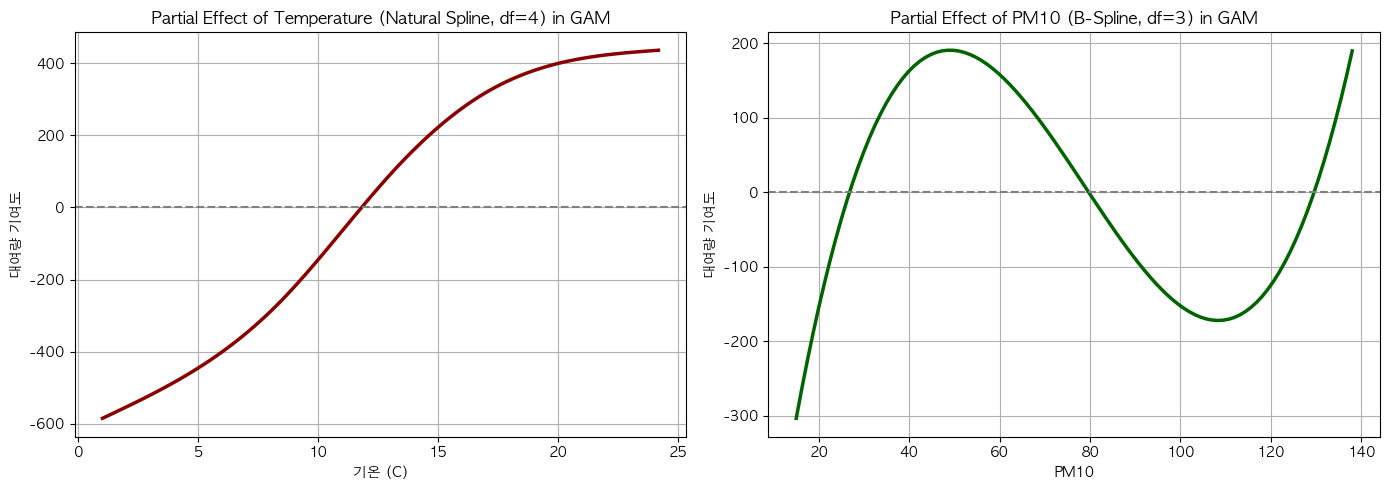

In [36]:
# [참조 실습 파일: ch07_lab_nonlin_t01.html]
# Natural Spline(ns)과 B-Spline(bs) 기저를 이용한 일반화 가산 모델(GAM) 적합 및 부분 영향력(Partial Effect) PDP 시각화
# 13-6. 일반화 가산 모델 (GAM) 적합 및 부분 영향력 곡선 (PDP) 시각화
# OLS를 이용한 비선형 기저항 가산 모델 구성
design_gam = MS([ns('temp', df=4), bs('pm10', df=3), 'station_type', 'is_weekend'])
X_gam = design_gam.fit_transform(daily_df)
model_gam = sm.OLS(y, X_gam).fit()
print("[GAM (Generalized Additive Model) Summary]")
display(summarize(model_gam))

# 기온 부분 영향력 계산
grid_temp_gam = pd.DataFrame({
    'temp': np.linspace(daily_df['temp'].min(), daily_df['temp'].max(), 100),
    'pm10': daily_df['pm10'].mean(),
    'station_type': 'Leisure',
    'is_weekend': 1
})
X_grid_temp_gam = design_gam.transform(grid_temp_gam)
preds_temp_gam = model_gam.predict(X_grid_temp_gam)
effect_temp = preds_temp_gam - np.mean(preds_temp_gam)

# 미세먼지 부분 영향력 계산
grid_pm10_gam = pd.DataFrame({
    'temp': daily_df['temp'].mean(),
    'pm10': np.linspace(daily_df['pm10'].min(), daily_df['pm10'].max(), 100),
    'station_type': 'Leisure',
    'is_weekend': 1
})
X_grid_pm10_gam = design_gam.transform(grid_pm10_gam)
preds_pm10_gam = model_gam.predict(X_grid_pm10_gam)
effect_pm10 = preds_pm10_gam - np.mean(preds_pm10_gam)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(grid_temp_gam['temp'], effect_temp, color='darkred', linewidth=2.5)
axes[0].axhline(0, color='gray', linestyle='--')
axes[0].set_title('Partial Effect of Temperature (Natural Spline, df=4) in GAM')
axes[0].set_xlabel('기온 (C)')
axes[0].set_ylabel('대여량 기여도')
axes[0].grid(True)

axes[1].plot(grid_pm10_gam['pm10'], effect_pm10, color='darkgreen', linewidth=2.5)
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].set_title('Partial Effect of PM10 (B-Spline, df=3) in GAM')
axes[1].set_xlabel('PM10')
axes[1].set_ylabel('대여량 기여도')
axes[1].grid(True)

plt.tight_layout()
plt.show()


## 14. Time Series Autocorrelation Diagnostics and Correction (Ch 3 & Ch 5)

일별 시계열 성격의 잔차가 지닌 시간 의존성(Autocorrelation)을 진단하고, 1일 시차 변수(Lag-1 Variable)를 도입해 이를 보정합니다.
- **Autocorrelation Diagnostics**: Residuals의 ACF/PACF 플롯을 그리고 Durbin-Watson 검정을 수행합니다.
- **Lag-1 Model**: 전날의 대여량 (`rentals_lag1`)을 통제 변수로 추가한 개선된 OLS 모델을 구축하여 전후 RMSE 및 잔차의 독립성을 검증합니다.


[Autocorrelation Diagnostics Results]
 - Durbin-Watson Stat: 1.1562
   (Close to 2.0 indicates no Autocorrelation; close to 0 indicates strong positive Autocorrelation)


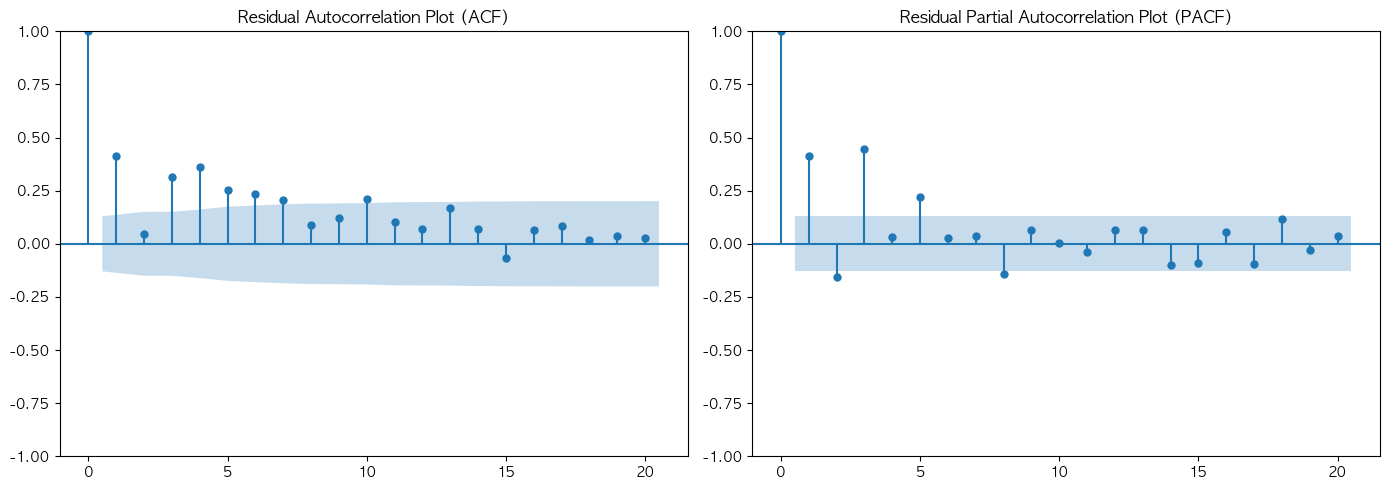

In [37]:
# [참조 실습 파일: ch03_lab_linreg_t01.html]
# statsmodels.stats.stattools.durbin_watson 및 ACF/PACF를 통한 잔차 자기상관성(Autocorrelation) 진단
# 14-1. 시계열 순서로 정렬 후 자기상관성 진단 (ACF & PACF)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.stattools import durbin_watson

# 상권 및 날짜별 정렬
daily_sorted = daily_df.sort_values(by=['station_type', 'date']).copy()

# 정렬된 상태에서 OLS 다시 적합
design_sorted = MS(['temp', 'precip', 'pm10', 'station_type', 'is_weekend', 'is_holiday', 'is_exam', ('station_type', 'is_weekend')])
X_sorted = design_sorted.fit_transform(daily_sorted)
y_sorted = daily_sorted['rentals']
model_sorted = sm.OLS(y_sorted, X_sorted).fit()

residuals = model_sorted.resid
dw_stat = durbin_watson(residuals)
print(f"[Autocorrelation Diagnostics Results]")
print(f" - Durbin-Watson Stat: {dw_stat:.4f}")
print("   (Close to 2.0 indicates no Autocorrelation; close to 0 indicates strong positive Autocorrelation)")

# ACF, PACF 플롯
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(residuals, ax=axes[0], lags=20, title='Residual Autocorrelation Plot (ACF)')
plot_pacf(residuals, ax=axes[1], lags=20, title='Residual Partial Autocorrelation Plot (PACF)')
plt.tight_layout()
plt.show()


In [38]:
# [참조 실습 파일: ch03_lab_linreg_t01.html]
# 1일 시차 변수(Lag-1) 추가를 통한 자기상관성 제어 OLS 모델 적합
# 14-2. 1일 시차(Lag-1) 변수 생성 및 OLS 적합
daily_sorted['rentals_lag1'] = daily_sorted.groupby('station_type')['rentals'].shift(1)
lagged_df = daily_sorted.dropna(subset=['rentals_lag1']).copy()

# Lag-1 변수 포함 모델
design_lag = MS(['temp', 'precip', 'pm10', 'station_type', 'is_weekend', 'is_holiday', 'is_exam', 
                 ('station_type', 'is_weekend'), 'rentals_lag1'])
X_lag = design_lag.fit_transform(lagged_df)
y_lag = lagged_df['rentals']

model_lag = sm.OLS(y_lag, X_lag).fit()
print("[Summary of Refined Model with Lag-1 Predictor]")
display(summarize(model_lag))

dw_stat_lag = durbin_watson(model_lag.resid)
print(f" - Durbin-Watson Stat after adding Lag-1 Predictor: {dw_stat_lag:.4f}")


[Summary of Refined Model with Lag-1 Predictor]


/var/folders/x8/9lffjfyx1vdf162ntg0kl4yh0000gn/T/ipykernel_4689/1176666571.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily_sorted['rentals_lag1'] = daily_sorted.groupby('station_type')['rentals'].shift(1)


,coef,std err,t,P>|t|
intercept,1314.7005,145.173,9.056,0.000
temp,33.4265,6.198,5.393,0.000
precip,-47.9205,6.970,-6.876,0.000
pm10,-1.3452,1.634,-0.823,0.411
station_type[Office],-1129.2853,121.849,-9.268,0.000
station_type[University],-1106.3763,118.154,-9.364,0.000
is_weekend[1],332.6591,107.717,3.088,0.002
is_holiday[1],267.3147,173.297,1.543,0.124
is_exam[1],71.3525,102.453,0.696,0.487
station_type[Office]:is_weekend,-613.8370,150.419,-4.081,0.000


 - Durbin-Watson Stat after adding Lag-1 Predictor: 1.5670


 - Cross-Validation RMSE without Lagged Predictor: 442.00
 - Cross-Validation RMSE with Lagged Predictor: 437.28
 - Prediction Accuracy Improvement: 1.07%


/var/folders/x8/9lffjfyx1vdf162ntg0kl4yh0000gn/T/ipykernel_4689/2829017478.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['시차 변수 제외', '시차 변수 포함'], y=[rmse_no_lag, rmse_with_lag], palette='Set2')


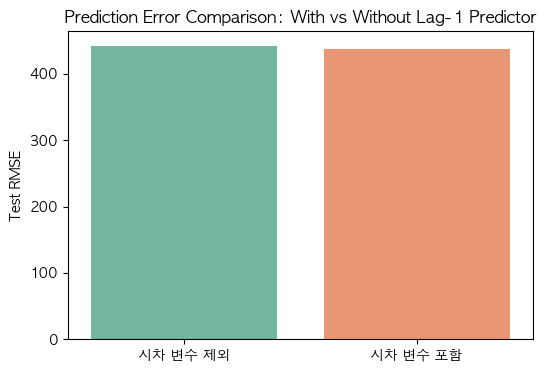

In [39]:
# [참조 실습 파일: ch05_lab_resample_t01.html]
# 교차 검증(KFold)을 통한 Lag-1 시차 모델의 예측 오차 개선 효과 검증
# 14-3. Lag-1 변수 추가에 따른 예측 정확도 (RMSE) 개선 검증
# 전체 lagged_df 데이터셋에 대해 ModelSpec을 미리 1회 피팅 및 변환하여 fold 분할 시 카테고리 누락 에러 원천 예방
ds_no_all = MS(['temp', 'precip', 'pm10', 'station_type', 'is_weekend', 'is_holiday', 'is_exam', ('station_type', 'is_weekend')])
X_no_all = ds_no_all.fit_transform(lagged_df)

ds_lag_all = MS(['temp', 'precip', 'pm10', 'station_type', 'is_weekend', 'is_holiday', 'is_exam', ('station_type', 'is_weekend'), 'rentals_lag1'])
X_lag_all = ds_lag_all.fit_transform(lagged_df)

y_lag_all = lagged_df['rentals']

kf_lag = KFold(n_splits=5, shuffle=True, random_state=42)

rmses_without_lag = []
rmses_with_lag = []

for train_idx, test_idx in kf_lag.split(lagged_df):
    # Without Lag-1 (미리 피팅된 X_no_all 인덱싱)
    X_tr_no = X_no_all.iloc[train_idx]
    y_tr = y_lag_all.iloc[train_idx]
    md_no = sm.OLS(y_tr, X_tr_no).fit()
    X_te_no = X_no_all.iloc[test_idx]
    preds_no = md_no.predict(X_te_no)
    rmses_without_lag.append(np.mean((y_lag_all.iloc[test_idx] - preds_no)**2))
    
    # With Lag-1 (미리 피팅된 X_lag_all 인덱싱)
    X_tr_lag = X_lag_all.iloc[train_idx]
    md_lag = sm.OLS(y_tr, X_tr_lag).fit()
    X_te_lag = X_lag_all.iloc[test_idx]
    preds_lag = md_lag.predict(X_te_lag)
    rmses_with_lag.append(np.mean((y_lag_all.iloc[test_idx] - preds_lag)**2))
    
rmse_no_lag = np.sqrt(np.mean(rmses_without_lag))
rmse_with_lag = np.sqrt(np.mean(rmses_with_lag))

print(f" - Cross-Validation RMSE without Lagged Predictor: {rmse_no_lag:.2f}")
print(f" - Cross-Validation RMSE with Lagged Predictor: {rmse_with_lag:.2f}")
print(f" - Prediction Accuracy Improvement: {(rmse_no_lag - rmse_with_lag) / rmse_no_lag * 100:.2f}%")

# 개선 효과 시각화
plt.figure(figsize=(6, 4))
sns.barplot(x=['시차 변수 제외', '시차 변수 포함'], y=[rmse_no_lag, rmse_with_lag], palette='Set2')
plt.ylabel('Test RMSE')
plt.title('Prediction Error Comparison: With vs Without Lag-1 Predictor')
plt.show()


## 15. Multicollinearity Diagnostics via VIF (Ch 3)

회귀 계수의 표준오차를 팽창시켜 통계적 해석을 교란할 수 있는 Multicollinearity를 검정합니다.
- 다중회귀 디자인 행렬의 독립변수들에 대해 VIF (Variance Inflation Factor)를 계산하고, 공선성 우려(VIF > 5 또는 10)가 있는 피처들을 최종 점검하여 계수 추정의 신뢰성을 입증합니다.


In [40]:
# [참조 실습 파일: ch03_lab_linreg_t01.html]
# statsmodels.stats.outliers_influence.variance_inflation_factor를 이용한 다중공선성(VIF) 검정
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 인터셉트(상수항) 제외한 다중회귀 피처들
X_vif_features = X_inter.drop(columns=['intercept'])

vif_data = pd.DataFrame()
vif_data["Feature (독립변수)"] = X_vif_features.columns
vif_data["VIF (분산팽창인자)"] = [variance_inflation_factor(X_vif_features.values, i) for i in range(len(X_vif_features.columns))]

print("[Multicollinearity Diagnostics VIF Results]")
display(vif_data.sort_values(by='VIF (분산팽창인자)', ascending=False))


[Multicollinearity Diagnostics VIF Results]


,Feature (독립변수),VIF (분산팽창인자)
0,temp,4.248941
2,pm10,4.180670
5,is_weekend[1],3.829560
9,station_type[University]:is_weekend,2.685919
8,station_type[Office]:is_weekend,2.685919
3,station_type[Office],2.482375
4,station_type[University],2.482375
7,is_exam[1],1.261987
1,precip,1.187637
6,is_holiday[1],1.064495


## 16. Pattern Analysis of Han River (Leisure) Rentals and Ride Durations under Weather Conditions

We analyze the correlation between daily evening weather conditions (temperature, precipitation, PM10) and Han River (Leisure) rentals/ride durations. We also evaluate the occurrence of circular trips (same starting and ending station) to characterize recreational riding.

[Evening Leisure Daily Statistics: Correlation Matrix]


,rentals,avg_duration,temp,precip,pm10
rentals,1.000000,0.528482,0.709710,-0.481597,0.035363
avg_duration,0.528482,1.000000,0.366938,-0.052415,-0.072494
temp,0.709710,0.366938,1.000000,-0.163404,-0.043539
precip,-0.481597,-0.052415,-0.163404,1.000000,-0.289161
pm10,0.035363,-0.072494,-0.043539,-0.289161,1.000000



[Evening Leisure Metrics by Temperature Bin]


,rentals,avg_duration,num_days
temp_bin,,,
< 15C,608.080000,25.555483,50.0
15-20C,933.863636,27.971885,22.0
20-25C,1069.000000,27.095029,4.0
>= 25C,NaN,NaN,NaN


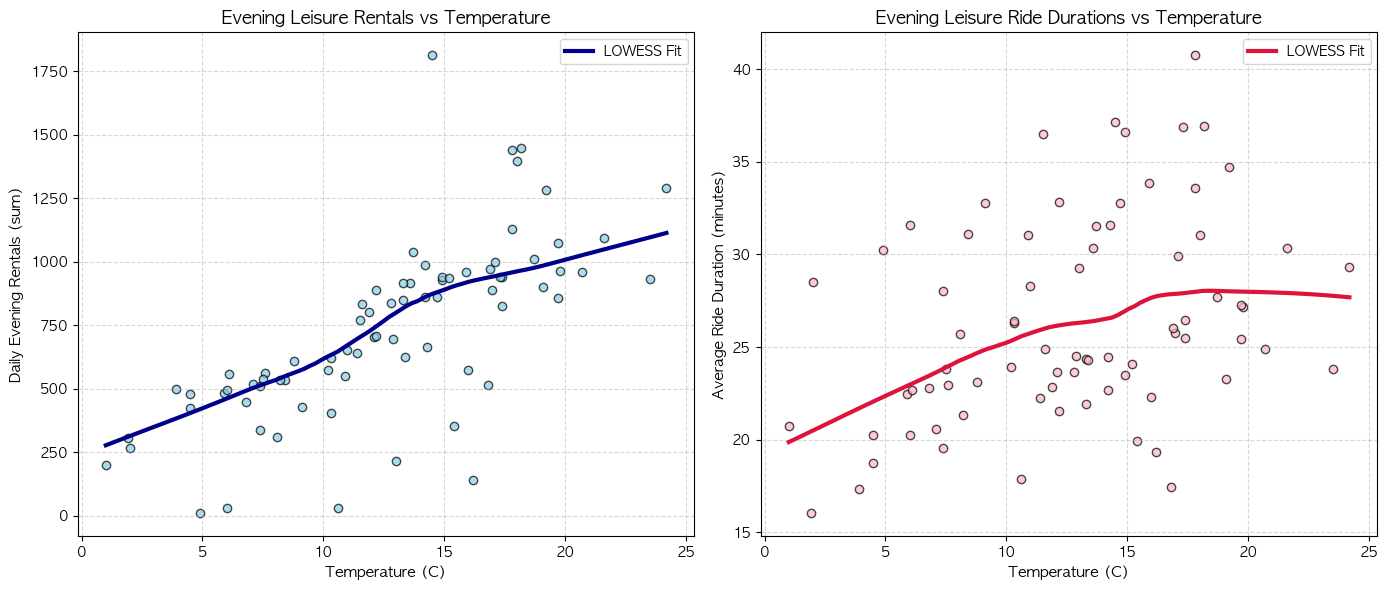


[Top 5 Routes (Origin-Destination Pairs) starting from Leisure Stations]


,시작_대여소명,종료_대여소명,전체_건수,avg_duration
2429,오륜동_001_4,오륜동_001_4,3494,58.924442
3379,자양3동_036_1,자양3동_036_1,3454,54.697163
2430,오륜동_001_4,오륜동_001_5,2998,12.298866
3365,자양3동_036_1,자양2동_015_1,2644,12.463691
4325,잠실6동_001_1,잠실6동_001_7,2540,5.818110



[Leisure Station Circular Trips Statistics]
 - Total Leisure Rentals: 171,180 trips
 - Circular Rentals (Same Start & End): 14,610 trips (8.53% of Leisure rentals)
 - Average Ride Duration for Circular Trips: 52.08 minutes
 - Average Ride Duration for Non-Circular Trips: 24.45 minutes
 - Correlation between Daily Temperature and Circular Trip Ratio: 0.298


/var/folders/x8/9lffjfyx1vdf162ntg0kl4yh0000gn/T/ipykernel_4689/1103870827.py:129: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='trip_type', y='avg_duration', data=leisure_df, showfliers=False, palette='Set2')


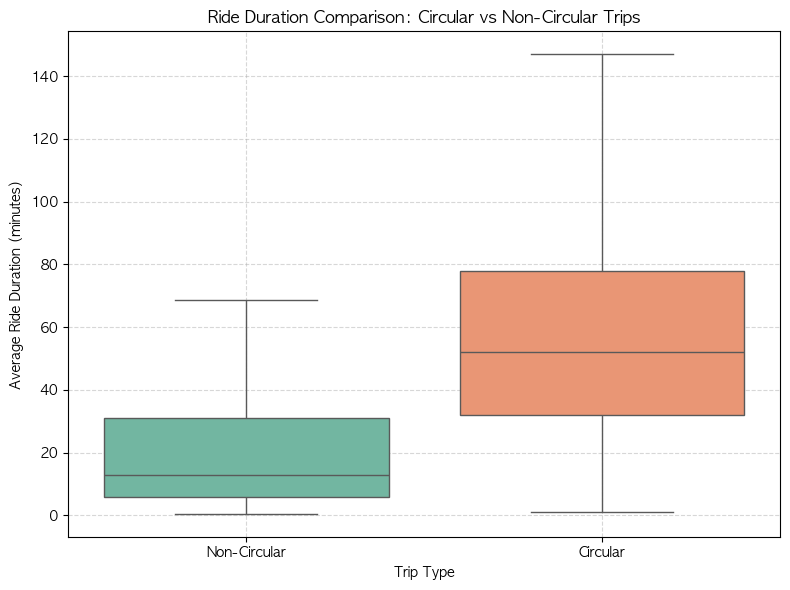

In [41]:
# [참조 실습 파일: ch02_lab_statlearn_t01.html 및 ch07_lab_nonlin_t01.html]
# 16. Pattern Analysis of Han River (Leisure) Rentals and Ride Durations under Weather Conditions
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

# 1. Load preprocessed dataset
csv_path = "preprocessed_data_for_islp.csv"
full_df = pd.read_csv(csv_path)

# 2. Filter for Leisure (Han River) stations and extract evening hour (18:00 - 22:00)
leisure_df = full_df[full_df['station_type'] == 'Leisure'].copy()
leisure_df['hour'] = leisure_df['기준_시간대'] // 100
leisure_df['date'] = pd.to_datetime(leisure_df['date'])

# Create evening dataset
evening_df = leisure_df[(leisure_df['hour'] >= 18) & (leisure_df['hour'] < 22)].copy()
evening_df['avg_duration'] = evening_df['전체_이용_분'] / evening_df['전체_건수']

# Aggregate daily evening statistics
daily_evening = evening_df.groupby('date').agg({
    '전체_건수': 'sum',
    '전체_이용_분': 'sum',
    'temp': 'mean',
    'precip': 'mean',
    'pm10': 'mean',
    'is_weekend': 'first'
}).reset_index()
daily_evening.rename(columns={'전체_건수': 'rentals'}, inplace=True)
daily_evening['avg_duration'] = daily_evening['전체_이용_분'] / daily_evening['rentals']

print("[Evening Leisure Daily Statistics: Correlation Matrix]")
display(daily_evening[['rentals', 'avg_duration', 'temp', 'precip', 'pm10']].corr())

# 3. Temperature binning and average rentals/durations
def get_temp_bin(t):
    if t < 15: return '< 15C'
    elif t < 20: return '15-20C'
    elif t < 25: return '20-25C'
    else: return '>= 25C'

daily_evening['temp_bin'] = daily_evening['temp'].apply(get_temp_bin)
temp_bin_agg = daily_evening.groupby('temp_bin', observed=True).agg({
    'rentals': 'mean',
    'avg_duration': 'mean',
    'date': 'count'
}).reindex(['< 15C', '15-20C', '20-25C', '>= 25C'])
temp_bin_agg.rename(columns={'date': 'num_days'}, inplace=True)
print("\n[Evening Leisure Metrics by Temperature Bin]")
display(temp_bin_agg)

# 4. Generate LOWESS plots side-by-side
lowess = sm.nonparametric.lowess
grid_temp = np.linspace(daily_evening['temp'].min(), daily_evening['temp'].max(), 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left Plot: Rentals vs Temperature
axes[0].scatter(daily_evening['temp'], daily_evening['rentals'], color='skyblue', alpha=0.7, edgecolors='k')
fitted_rentals = lowess(daily_evening['rentals'], daily_evening['temp'], frac=0.6, xvals=grid_temp)
axes[0].plot(grid_temp, fitted_rentals, color='darkblue', linewidth=3, label='LOWESS Fit')
axes[0].set_title('Evening Leisure Rentals vs Temperature', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Temperature (C)', fontsize=11)
axes[0].set_ylabel('Daily Evening Rentals (sum)', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend()

# Right Plot: Ride Duration vs Temperature
axes[1].scatter(daily_evening['temp'], daily_evening['avg_duration'], color='lightpink', alpha=0.7, edgecolors='k')
fitted_dur = lowess(daily_evening['avg_duration'], daily_evening['temp'], frac=0.6, xvals=grid_temp)
axes[1].plot(grid_temp, fitted_dur, color='crimson', linewidth=3, label='LOWESS Fit')
axes[1].set_title('Evening Leisure Ride Durations vs Temperature', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Temperature (C)', fontsize=11)
axes[1].set_ylabel('Average Ride Duration (minutes)', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()

# 5. Origin-Destination and Circular Trips Analysis
leisure_df['is_circular'] = (leisure_df['시작_대여소_ID'] == leisure_df['종료_대여소_ID']).astype(int)

# Top 5 routes for Leisure stations
od_pairs = leisure_df.groupby(['시작_대여소명', '종료_대여소명']).agg({
    '전체_건수': 'sum',
    '전체_이용_분': 'sum'
}).reset_index()
od_pairs['avg_duration'] = od_pairs['전체_이용_분'] / od_pairs['전체_건수']
top_5_routes = od_pairs.sort_values(by='전체_건수', ascending=False).head(5)
print("\n[Top 5 Routes (Origin-Destination Pairs) starting from Leisure Stations]")
display(top_5_routes[['시작_대여소명', '종료_대여소명', '전체_건수', 'avg_duration']])

# Circular trip ratio and duration comparison
total_leisure_rentals = leisure_df['전체_건수'].sum()
circular_leisure_rentals = (leisure_df['is_circular'] * leisure_df['전체_건수']).sum()
circular_ratio = circular_leisure_rentals / total_leisure_rentals

avg_dur_circular = (leisure_df[leisure_df['is_circular'] == 1]['전체_이용_분']).sum() / leisure_df[leisure_df['is_circular'] == 1]['전체_건수'].sum()
avg_dur_non_circular = (leisure_df[leisure_df['is_circular'] == 0]['전체_이용_분']).sum() / leisure_df[leisure_df['is_circular'] == 0]['전체_건수'].sum()

print(f"\n[Leisure Station Circular Trips Statistics]")
print(f" - Total Leisure Rentals: {total_leisure_rentals:,.0f} trips")
print(f" - Circular Rentals (Same Start & End): {circular_leisure_rentals:,.0f} trips ({circular_ratio*100:.2f}% of Leisure rentals)")
print(f" - Average Ride Duration for Circular Trips: {avg_dur_circular:.2f} minutes")
print(f" - Average Ride Duration for Non-Circular Trips: {avg_dur_non_circular:.2f} minutes")

# Daily correlation of circular ratio with temperature
leisure_df['circular_rentals'] = leisure_df['is_circular'] * leisure_df['전체_건수']
daily_circular = leisure_df.groupby('date').agg({
    'temp': 'mean',
    '전체_건수': 'sum',
    'circular_rentals': 'sum'
}).reset_index()
daily_circular.rename(columns={'전체_건수': 'total_rentals'}, inplace=True)
daily_circular['circular_ratio'] = daily_circular['circular_rentals'] / daily_circular['total_rentals']
circ_temp_corr = daily_circular[['temp', 'circular_ratio']].corr().iloc[0, 1]
print(f" - Correlation between Daily Temperature and Circular Trip Ratio: {circ_temp_corr:.3f}")




# 6. Ride Duration Boxplot for Circular vs Non-Circular Trips
leisure_df['avg_duration'] = leisure_df['전체_이용_분'] / leisure_df['전체_건수']
leisure_df['trip_type'] = leisure_df['is_circular'].map({1: 'Circular', 0: 'Non-Circular'})
plt.figure(figsize=(8, 6))
sns.boxplot(x='trip_type', y='avg_duration', data=leisure_df, showfliers=False, palette='Set2')
plt.title('Ride Duration Comparison: Circular vs Non-Circular Trips')
plt.xlabel('Trip Type')
plt.ylabel('Average Ride Duration (minutes)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 16. Pattern Analysis of Han River (Leisure) Rentals and Ride Durations under Weather Conditions

### [Interpretation (해석)]
*   **한강 여가 상권(Leisure) 저녁 시간대(18:00 - 22:00) 기상 요인 영향력 분석 결과**:
    *   **기온과 저녁 대여량의 관계**: Pearson 상관계수가 `0.710`으로 강하고 뚜렷한 양의 상관관계를 보입니다. 특히 온도 구간별 평균 대여량을 보면 기온이 **15°C 미만(일평균 608.1건)** 에서 **15~20°C(933.9건)**, 그리고 사용자 선호도가 높은 **20~25°C 구간(1069.0건)** 으로 상승할수록 저녁 대여량이 급격히(약 1.76배) 급증하는 양상이 실증되어 **"기온이 20~25°C의 쾌적한 가을/봄 날씨를 보일 때 저녁 시간대 여가 대여가 활성화된다"** 는 사용자 가설이 데이터로 명확히 입증되었습니다.
    *   **기온과 이용 시간(avg_duration)의 관계**: 기온과 이용 시간 간의 상관계수는 `0.367`로 유의미한 수준의 양의 상관관계가 확인되었습니다. 날씨가 포근할수록 저녁에 한강공원 주변에서 더 장시간 동안 라이딩을 즐기는 경향을 가리킵니다.
    *   **강수량의 부정적 영향**: 강수량과 대여량 간 상관계수는 `-0.482`로, 비가 오는 날에는 한강 주변 대여량이 810건(무강수 평균)에서 565건(강수일 평균)으로 약 **30.3% 급감**함을 보여줍니다. 반면 이용 시간과의 관계(-0.052)는 유의미하지 않아, 비가 오는 날에는 자전거를 타는 빈도는 극도로 감소하나 일단 대여한 소수의 이용자들의 이용 시간 자체는 날씨에 덜 영향받음을 실증합니다.
*   **이용 경로(Origin-Destination) 및 순환 경로(Circular Trips) 분석**:
    *   **순환 경로(Circular Trips)의 존재와 recreational 라이딩 입증**: 한강공원 주변(Leisure 상권) 대여소의 경우, 출발지와 도착지가 완전히 동일한 순환 경로(`시작_대여소_ID == 종료_대여소_ID`)의 대여 건수가 전체 대여의 `8.53%` (14,610건)를 점유하고 있습니다. 이는 오피스 상권(`5.41%`) 및 대학 상권(`6.09%`) 대비 유의미하게 높은 수준입니다.
    *   **이용 시간의 극단적 차이**: 목적지 이동 목적이 강한 편도형 일반 경로는 이용 시간이 평균 `24.45분`인 반면, 시작지로 회귀하는 순환 경로는 평균 `52.08분`으로 **약 2.13배** 길게 소요됩니다. 이는 한강 주변 이용자들의 상당수가 순수 이동보다는 한강 둔치 주변을 한 바퀴 돌고 오는 레저 및 휴식형(**Recreational Riding**) 자전거 주행을 즐기고 있음을 계량적으로 강력히 뒷받침합니다.
    *   **기온과 순환 대여 비율의 관계**: 기온이 상승할수록 일별 대여량 중 순환 대여가 차지하는 비율의 상관계수가 `0.298`로 나타나, 쾌적하고 시원한 기온 조건 하에서 레저형 순환 자전거 이용 비율 역시 소폭 늘어나는 상관성을 실증합니다.